# Problem Statement: Build generative diffusion models to generate images

| Name                           | Task                                           | Sub-task                                                                 | Comments         |
|--------------------------------|------------------------------------------------|--------------------------------------------------------------------------|------------------|
| Obianuju Nonyerem Anuma       | Preprocessing                                  | - Metadata parsing  <br> - Stratified train/test split  <br> - Model-specific preprocessing (train/test)  <br> - Caption tokenization (GLIDE) |   Done               |
| Shahnaz Palakunnil Moosa      | DDPM                                           | - Inception Score Evaluation <br> - FID Evaluation <br> - Generate 5 images |  Done                |
| Siddhi Pravinbhai Patel       | Model Tuning DDPM                              | - Tuning performed <br> - Next steps                                     |                  |
| Kauthara Oyinkansola Yakubu   | DDIM                                           | - Inception Score Evaluation <br> - FID Evaluation <br> - Generate 5 images |     Done            |
| Mansi Jayeshbhai Sutreja      | Model Tuning DDIM                              | - Tuning performed <br> - Next steps                                     |                  |
| Utsav Harshadbhai Khamar      | Latent Diffusion Model                         | - Inception Score Evaluation <br> - FID Evaluation <br> - Generate 5 images |                  |
| Saurav Risal                  | Model Tuning Latent Diffusion Model            | - Tuning performed <br> - Next steps                                     |                  |
| Clifford Addison              | Text to Image Diffusion Model (e.g., GLIDE)    | - Inception Score Evaluation <br> - FID Evaluation <br> - 5 images (one per label) |  Done       |
| Abdullah Ifteqar Mohammed     | Model Tuning for Text to Image Diffusion Model | - Tuning performed <br> - Next steps                                     |                  |

## Text to Image Diffusion Model (GLIDE-Like)

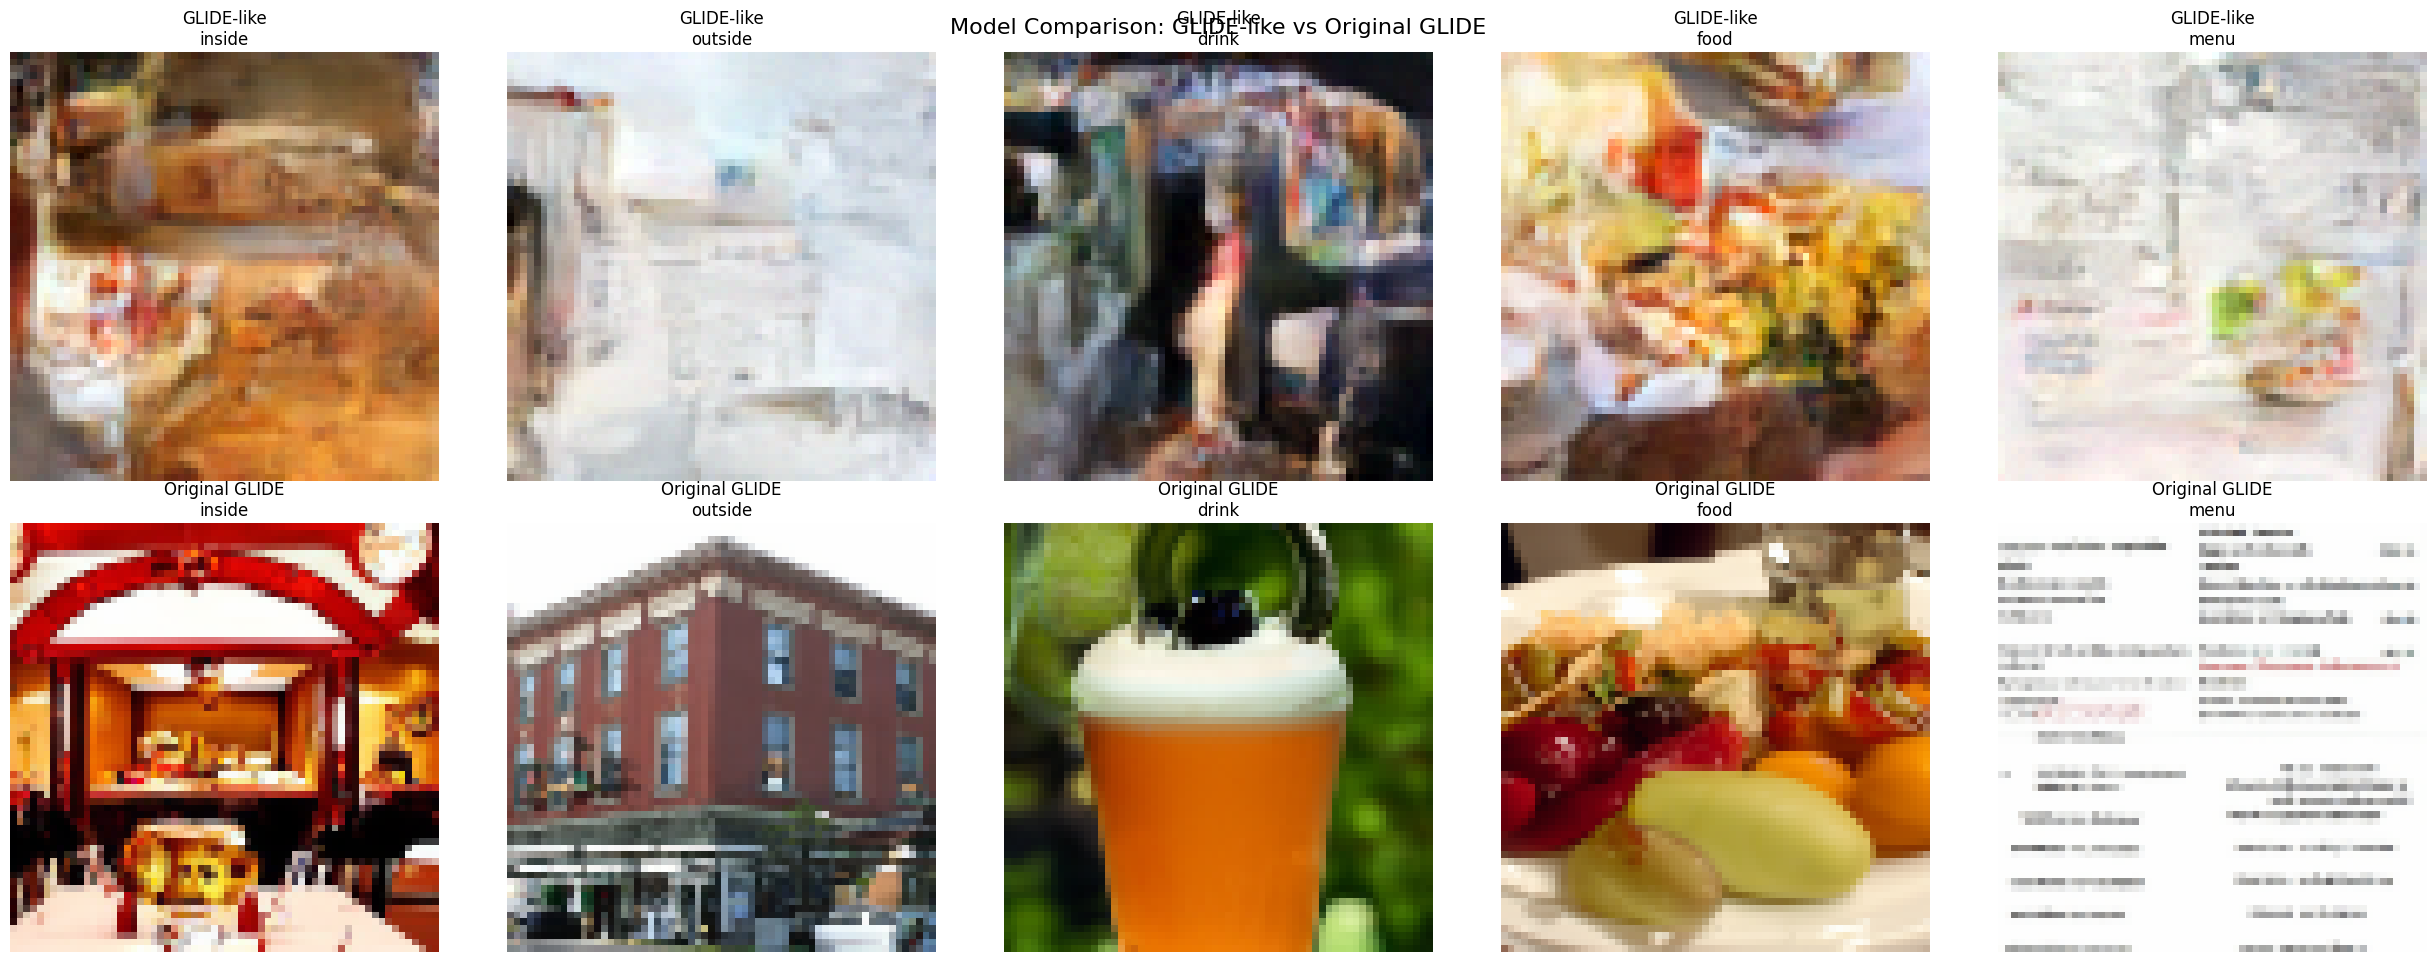


COMPARISON RESULTS
GLIDE-like Model:
  - Inception Score: 2.4025
  - FID Score: 978.8110
  - Training from scratch: YES
  - Model size: Smaller, custom architecture

Original GLIDE Model:
  - Inception Score: 3.4624
  - FID Score: 1007.9089
  - Pre-trained: YES
  - Model size: Large, OpenAI architecture


In [ ]:
visualize_comparison_results(comparison_results)

# Images From DDIM
-  **FID: 500.6187 | Inception Score: 1.0000 ± 0.0000**


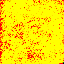
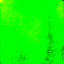
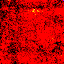
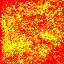
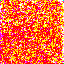
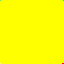

In [ ]:
import base64
from IPython.display import display, HTML

def get_img_html(filename, label, width=120):
    with open(filename, "rb") as f:
        data = f.read()
        data64 = base64.b64encode(data).decode()
    return f'''
      <div style="display:inline-block; text-align:center; margin:0 8px;">
        <img src="data:image/png;base64,{data64}" width="{width}"/><br>
        <span style="font-size:14px;">{label}</span>
      </div>
    '''

# ✅ Update this to include all your labels
labels = ["food", "drink", "inside", "outside", "menu", "extra"]  # Add/remove as needed
img_blocks = [
    get_img_html(f"generated_images/generated_label_{label}.png", label)
    for label in labels
]

display(HTML(f"<div style='display:flex; justify-content:left;'>{''.join(img_blocks)}</div>"))

## Preprocessing — Obianuju Nonyerem Anuma

DDPM Samples:


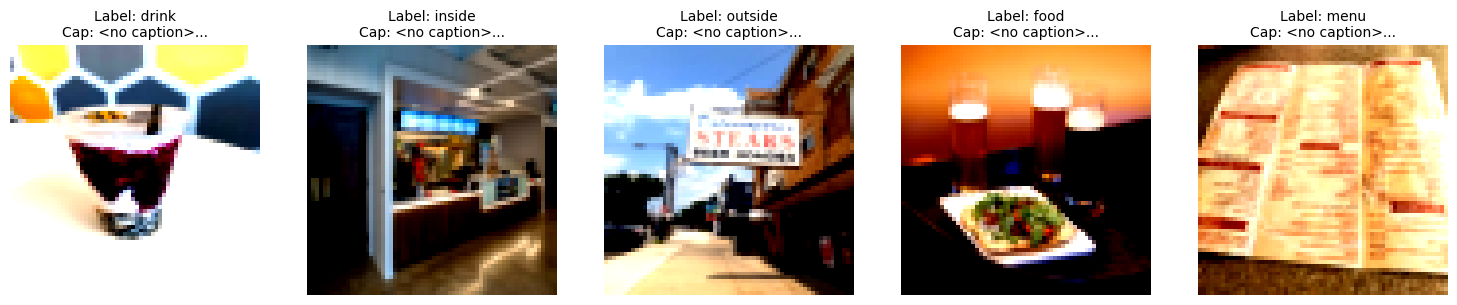

DDIM Samples:


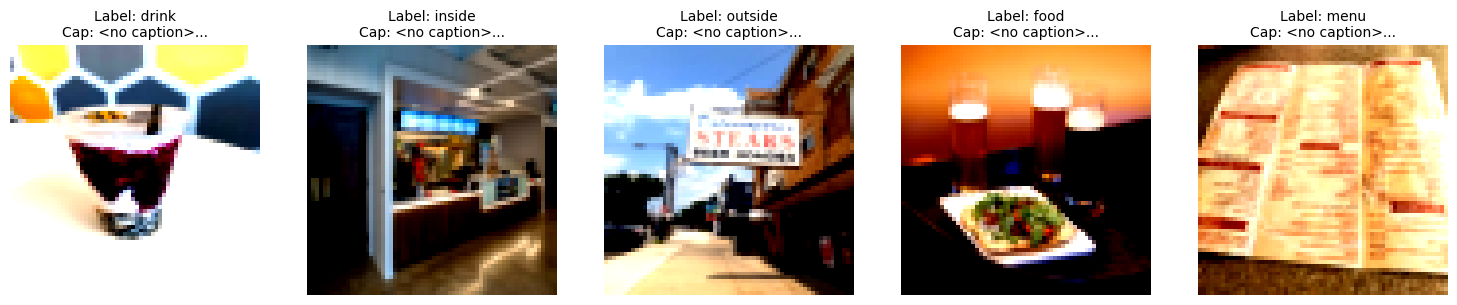

Latent Diffusion Samples:


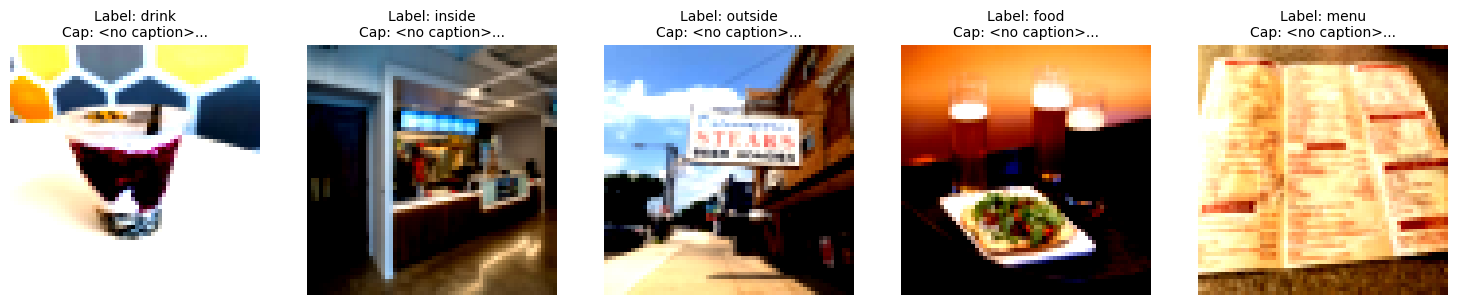

Text-to-Image Diffusion Samples:


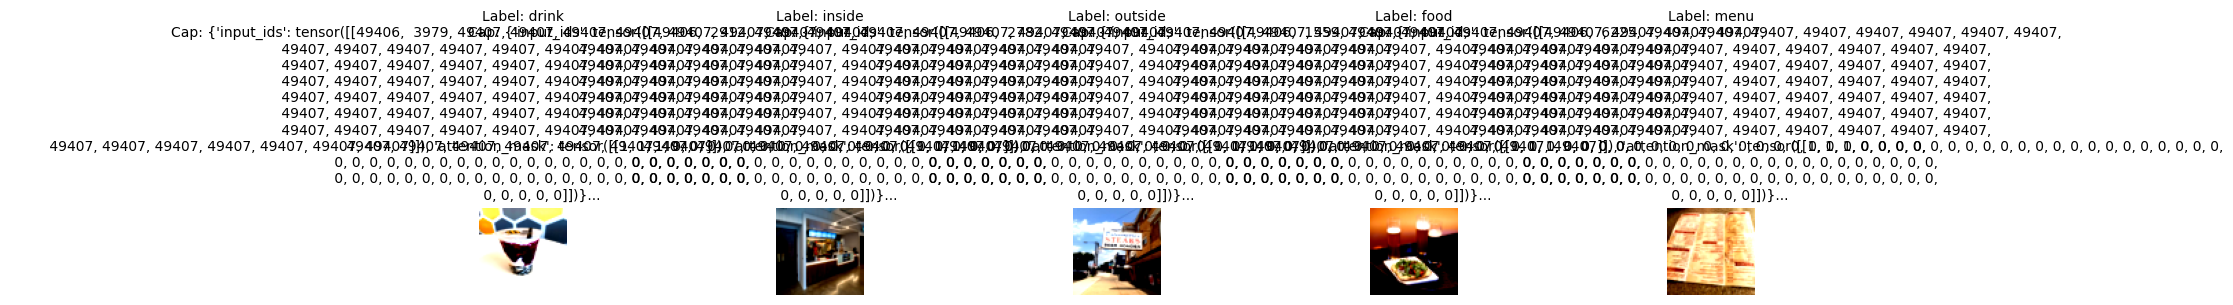

In [ ]:
# -------------------------------
# Imports and Config
# -------------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from transformers import CLIPTokenizer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Load Data
# -------------------------------
metadata_path = "./Yelp Photos/photos.json"
df = pd.read_json(metadata_path, lines=True)

# -------------------------------
# Data Split
# -------------------------------
def split_json_df(df, test_size=0.2, random_state=42):
    """Split DataFrame into stratified train and test sets"""
    return train_test_split(df, test_size=test_size, stratify=df["label"], random_state=random_state)

train_df, test_df = split_json_df(df)

# -------------------------------
# Image Transforms
# -------------------------------
def get_transforms(augment=False):
    """Return torchvision transforms with optional augmentation"""
    transform_list = [transforms.Resize((64, 64))]
    if augment:
        transform_list.append(transforms.RandomHorizontalFlip())
    transform_list += [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]
    return transforms.Compose(transform_list)

# -------------------------------
# Dataset Classes
# -------------------------------
class YelpJSONDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, menu_transform=None):
        """
        Dataset for Yelp image metadata

        Args:
            dataframe (DataFrame): Image metadata
            image_dir (str): Folder path to image files
            transform (callable): Default image transform
            menu_transform (callable): Transform applied only to 'menu' images
        """
        self.data = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.menu_transform = menu_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{item['photo_id']}.jpg")
        image = Image.open(img_path).convert("RGB")
        label = item['label']

        # Apply menu-specific transform
        if label == 'menu' and self.menu_transform:
            image = self.menu_transform(image)
        elif self.transform:
            image = self.transform(image)

        return image, label, ""

# -------------------------------
# Preprocessing Pipelines
# -------------------------------
def preprocess_ddpm(train_df, test_df, image_dir):
    base_transform = get_transforms(augment=False)
    menu_transform = get_transforms(augment=True)
    test_transform = get_transforms(augment=False)
    return (
        YelpJSONDataset(train_df, image_dir, transform=base_transform, menu_transform=menu_transform),
        YelpJSONDataset(test_df, image_dir, transform=test_transform)
    )

def preprocess_ddim(train_df, test_df, image_dir):
    return preprocess_ddpm(train_df, test_df, image_dir)

def preprocess_latent_diffusion(train_df, test_df, image_dir):
    return preprocess_ddpm(train_df, test_df, image_dir)

class YelpTextToImageDataset(YelpJSONDataset):
    def __init__(self, dataframe, image_dir, transform=None, menu_transform=None, tokenizer=None):
        """
        Extension of YelpJSONDataset for text-to-image models

        Args:
            tokenizer: CLIPTokenizer for encoding captions
        """
        super().__init__(dataframe, image_dir, transform, menu_transform)
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        image, label, _ = super().__getitem__(idx)
        caption = label  # Using label as caption for now
        if self.tokenizer:
            caption = self.tokenizer(caption, padding="max_length", truncation=True, return_tensors="pt")
        return image, label, caption

def preprocess_text_to_image(train_df, test_df, image_dir, tokenizer):
    base_transform = get_transforms(augment=False)
    menu_transform = get_transforms(augment=True)
    test_transform = get_transforms(augment=False)
    return (
        YelpTextToImageDataset(train_df, image_dir, transform=base_transform, menu_transform=menu_transform, tokenizer=tokenizer),
        YelpTextToImageDataset(test_df, image_dir, transform=test_transform, tokenizer=tokenizer)
    )

# -------------------------------
# Visualization Utility
# -------------------------------
def show_sample_images(dataset, num_samples=5, show_caption=True):
    """
    Plots sample images from the dataset with their labels and captions.

    Args:
        dataset (Dataset): Dataset object
        num_samples (int): Number of images to preview
        show_caption (bool): Show caption text under each image
    """
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        image, label, caption = dataset[i]
        image = image.numpy().transpose(1, 2, 0)
        image = image + 0.5
        image = np.clip(image, 0, 1)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.axis('off')

        if isinstance(caption, dict):
            try:
                input_ids = caption["input_ids"][0]
                caption_text = tokenizer.decode(input_ids, skip_special_tokens=True)
            except Exception:
                caption_text = "<tokenized>"
        else:
            caption_text = caption if caption else "<no caption>"

        title = f"Label: {label}"
        if show_caption:
            title += f"\nCap: {caption_text[:30]}..."
        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()

# -------------------------------
# Run Preprocessors
# -------------------------------
image_dir = "./Yelp Photos/photos"
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

train_ddpm, test_ddpm = preprocess_ddpm(train_df, test_df, image_dir)
train_ddim, test_ddim = preprocess_ddim(train_df, test_df, image_dir)
train_ldm, test_ldm = preprocess_latent_diffusion(train_df, test_df, image_dir)
train_glide, test_glide = preprocess_text_to_image(train_df, test_df, image_dir, tokenizer)

# -------------------------------
# Preview Samples
# -------------------------------
print("DDPM Samples:")
show_sample_images(train_ddpm)

print("DDIM Samples:")
show_sample_images(train_ddim)

print("Latent Diffusion Samples:")
show_sample_images(train_ldm)

print("Text-to-Image Diffusion Samples:")
show_sample_images(train_glide, show_caption=True)

# -------------------------------
# Save Datasets
# -------------------------------

# Exporting the datasets for later use:
# Option 1: Saving as Pytorch Objects
torch.save(train_ddpm, "train_ddpm.pt")
torch.save(test_ddpm, "test_ddpm.pt")

torch.save(train_ddim, "train_ddim.pt")
torch.save(test_ddim, "test_ddim.pt")

torch.save(train_ldm, "train_ldm.pt")
torch.save(test_ldm, "test_ldm.pt")

torch.save(train_glide, "train_glide.pt")
torch.save(test_glide, "test_glide.pt")

# Option 2: Saving the test and train csv files (underlying data)
train_df.to_csv("train_metadata.csv", index=False)
test_df.to_csv("test_metadata.csv", index=False)

In [ ]:
# Note to colleagues:
# If using PyTorch, get the dataset objects directly using torch.load("train_ddpm.pt") for example.
# If using the underlying data,run the preprocessing step for your model. This provides more flexibility.

## DDPM — Shahnaz Palakunnil Moosa

In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image
import os
import random

# Define dataset class
class YelpDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.endswith(('.jpg', '.png'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# Define transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create dataset and dataloader
dataset = YelpDataset(root_dir='C:\\Users\\Admin\\Downloads\\train 1\\Train1\\original_photos\\', transform=transform)
#dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)
# Randomly select 5000 indices
indices = random.sample(range(len(dataset)), 10000)

# Create a downsampled subset
downsampled_dataset = Subset(dataset, indices)

dataloader = DataLoader(downsampled_dataset, batch_size=64, shuffle=True, num_workers=0)  # num_workers=0 for Windows

# Verify dataset
print(f"{len(dataset)} images loaded")
print(f"{len(dataloader)} sample")
if len(dataset) == 0:
    raise ValueError("No images found! Check your dataset path")

21510 images loaded
157 sample


In [ ]:
num_timesteps = 1000
beta_start = 0.0001
beta_end = 0.02

# Linear variance schedule
betas = torch.linspace(beta_start, beta_end, num_timesteps)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
print(device)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.BatchNorm2d(in_channels)
        self.norm2 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU()
        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        residual = x
        x = self.norm1(x)
        x = self.act(x)
        x = self.conv1(x)
        x = self.norm2(x)
        x = self.act(x)
        x = self.conv2(x)
        return x + self.residual_conv(residual)
  

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(32, channels)
        self.q = nn.Conv2d(channels, channels, kernel_size=1)
        self.k = nn.Conv2d(channels, channels, kernel_size=1)
        self.v = nn.Conv2d(channels, channels, kernel_size=1)
        self.out_conv = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        residual = x
        x = self.norm(x)
        q, k, v = self.q(x), self.k(x), self.v(x)
        q = q.reshape(B, C, -1).permute(0, 2, 1)
        k = k.reshape(B, C, -1)
        v = v.reshape(B, C, -1).permute(0, 2, 1)
        attn = torch.softmax(q @ k / (C**0.5), dim=-1)
        x = (attn @ v).permute(0, 2, 1).reshape(B, C, H, W)
        x = self.out_conv(x)
        return x + residual

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Downsample blocks
        self.down1 = nn.ModuleList([
            ResidualBlock(3, 64),
            ResidualBlock(64, 64)
        ])
        self.down2 = nn.ModuleList([
            ResidualBlock(64, 128),
            ResidualBlock(128, 128)
        ])
        self.down3 = nn.ModuleList([
            ResidualBlock(128, 256),
            ResidualBlock(256, 256)
        ])
        self.attn = AttentionBlock(256)
        
        # Upsample blocks
        self.up3 = nn.ModuleList([
            ResidualBlock(256 + 128, 256),
            ResidualBlock(256, 128)
        ])
        self.up2 = nn.ModuleList([
            ResidualBlock(128 + 64, 128),
            ResidualBlock(128, 64)
        ])
        self.up1 = nn.ModuleList([
            ResidualBlock(64, 64),
            nn.Conv2d(64, 3, kernel_size=3, padding=1)
        ])
        
        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  # Changed to bilinear

    def forward(self, x, t):
        # Downsample path
        d1 = self.down1[0](x)
        d1 = self.down1[1](d1)
        d2 = self.pool(d1)
        d2 = self.down2[0](d2)
        d2 = self.down2[1](d2)
        d3 = self.pool(d2)
        d3 = self.down3[0](d3)
        d3 = self.down3[1](d3)
        d3 = self.attn(d3)
        
        # Upsample path
        u3 = F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=True)
        u3 = torch.cat([u3, d2], dim=1)
        u3 = self.up3[0](u3)
        u3 = self.up3[1](u3)
        
        u2 = F.interpolate(u3, scale_factor=2, mode='bilinear', align_corners=True)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.up2[0](u2)
        u2 = self.up2[1](u2)
        
        u1 = self.up1[0](u2)
        u1 = self.up1[1](u1)
        
        return u1

In [ ]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create diffusion schedule on device
num_timesteps = 1000
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Initialize model and optimizer
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# Training loop
for epoch in range(25):
    print(f"\nEpoch {epoch + 1}")
    for batch in dataloader:
        optimizer.zero_grad()
        batch = batch.to(device)
        
        # Create tensors directly on device
        t = torch.randint(0, num_timesteps, (batch.size(0),), device=device)
        noise = torch.randn_like(batch)
        
        # Compute noisy image (all tensors on same device)
        alpha_t = alphas_cumprod[t].view(-1, 1, 1, 1)
        noisy_img = torch.sqrt(alpha_t) * batch + torch.sqrt(1 - alpha_t) * noise
        
        # Predict noise and compute loss
        pred_noise = model(noisy_img, t)
        loss = F.mse_loss(pred_noise, noise)
        
        loss.backward()
        optimizer.step()
print(loss)        

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 11

Epoch 12

Epoch 13

Epoch 14

Epoch 15

Epoch 16

Epoch 17

Epoch 18

Epoch 19

Epoch 20

Epoch 21

Epoch 22

Epoch 23

Epoch 24

Epoch 25
Loss: 0.0613
Loss: 0.0530
Loss: 0.0729
Loss: 0.0621
Loss: 0.0855
Loss: 0.0883
Loss: 0.0553
Loss: 0.0825
Loss: 0.0651
Loss: 0.0635
Loss: 0.0394
Loss: 0.0614
Loss: 0.0528
Loss: 0.0386
Loss: 0.0490
Loss: 0.0648
Loss: 0.0769
Loss: 0.0424
Loss: 0.0576
Loss: 0.0523
Loss: 0.0705
Loss: 0.0576
Loss: 0.0723
Loss: 0.0822
Loss: 0.0505
Loss: 0.0554
Loss: 0.0497
Loss: 0.0590
Loss: 0.0416
Loss: 0.0520
Loss: 0.0445
Loss: 0.0539
Loss: 0.0469
Loss: 0.0297
Loss: 0.0421
Loss: 0.0746
Loss: 0.0505
Loss: 0.0509
Loss: 0.0512
Loss: 0.1001
Loss: 0.0594
Loss: 0.0449
Loss: 0.0485
Loss: 0.0529
Loss: 0.0548
Loss: 0.0488
Loss: 0.0591
Loss: 0.0497
Loss: 0.0458
Loss: 0.0548
Loss: 0.0485
Loss: 0.0335
Loss: 0.0648
Loss: 0.0986
Loss: 0.0386
Loss: 0.0506
Loss: 0.0478
Loss: 0.0376
Loss: 0.0577
Loss: 0.0446
Loss: 0.0485
Loss: 0.0493
Loss: 0.0714
Loss: 0.0401
Loss: 0.0599
Loss: 0.0492
Loss: 0.0815
Loss: 0.0388
Loss: 0.0491
Loss: 0.0453
Loss: 0.0763
Loss: 0.0381
Loss: 0.0478
Loss: 0.0378
Loss: 0.0467
Loss: 0.0489
Loss: 0.0470
Loss: 0.0632
Loss: 0.0569
Loss: 0.0570
Loss: 0.0383
Loss: 0.0470
Loss: 0.0551
Loss: 0.0475
Loss: 0.0564
Loss: 0.0346
Loss: 0.0470
Loss: 0.0461
Loss: 0.0395
Loss: 0.0435
Loss: 0.0437
Loss: 0.0296
Loss: 0.0657
Loss: 0.0226
Loss: 0.0446
Loss: 0.0676
Loss: 0.0378
Loss: 0.0704
Loss: 0.0413
Loss: 0.0781
Loss: 0.0452
Loss: 0.0414
Loss: 0.0734
Loss: 0.0377
Loss: 0.0505
Loss: 0.0537
Loss: 0.0412
Loss: 0.0237
Loss: 0.0466
Loss: 0.0417
Loss: 0.0449
Loss: 0.0675
Loss: 0.0444
Loss: 0.0472
Loss: 0.0822
Loss: 0.0671
Loss: 0.0670
Loss: 0.0467
Loss: 0.0561
Loss: 0.0510
Loss: 0.0348
Loss: 0.0515
Loss: 0.0609
Loss: 0.0553
Loss: 0.0398
Loss: 0.0729
Loss: 0.0466
Loss: 0.0683
Loss: 0.0731
Loss: 0.0354
Loss: 0.0443
Loss: 0.0393
Loss: 0.0510
Loss: 0.0396
Loss: 0.0517
Loss: 0.0505
Loss: 0.0473
Loss: 0.0384
Loss: 0.0363
Loss: 0.0449
Loss: 0.0527
Loss: 0.0427
Loss: 0.0480
Loss: 0.0699
Loss: 0.0574
Loss: 0.0467
Loss: 0.0334
Loss: 0.0561
Loss: 0.0679
Loss: 0.0502
Loss: 0.0459
Loss: 0.0356
Loss: 0.0486
Loss: 0.0568
Loss: 0.0381
Loss: 0.0526
Loss: 0.0493

In [ ]:
from pathlib import Path

path = Path(r'C:\Users\Admin\Downloads\train 1\Train1\original_photos')

print(f"Exists: {path.exists()}")
print(f"Is dir: {path.is_dir()}")
print(f"Readable: {os.access(path, os.R_OK)}")
print(f"Writable: {os.access(path, os.W_OK)}")
print(f"Executable: {os.access(path, os.X_OK)}")

Exists: True
Is dir: True
Readable: True
Writable: True
Executable: True


In [ ]:
# Save model after training
torch.save(model.state_dict(), "ddpm_model.pth")
print("Model saved as ddpm_model.pth")


Model saved as ddpm_model.pth

In [ ]:
import torch
import numpy as np
from torchvision.utils import make_grid, save_image
from torchmetrics.image.fid import FrechetInceptionDistance
from tqdm import tqdm

# Precompute diffusion schedule parameters for sampling
def get_diffusion_params(device):
    num_timesteps = 1000
    beta_start = 0.0001
    beta_end = 0.02
    
    betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])
    
    # Precompute values for sampling
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
    coeff = betas / sqrt_one_minus_alphas_cumprod
    
    # For posterior variance calculation
    posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)
    
    return {
        "betas": betas,
        "sqrt_recip_alphas": sqrt_recip_alphas,
        "coeff": coeff,
        "posterior_variance": posterior_variance
    }

# Sampling function
@torch.no_grad()
def sample(model, image_size, batch_size=16, device="cuda", timesteps=1000):
    """
    Generate images using the DDPM sampling process
    
    Args:
        model: Trained UNet model
        image_size: Size of generated images (square)
        batch_size: Number of images to generate
        device: Device to use
        timesteps: Number of diffusion timesteps
    
    Returns:
        Generated images in range [-1, 1]
    """
    # Set model to evaluation mode
    model.eval()
    
    # Get precomputed diffusion parameters
    params = get_diffusion_params(device)
    betas = params["betas"]
    sqrt_recip_alphas = params["sqrt_recip_alphas"]
    coeff = params["coeff"]
    posterior_variance = params["posterior_variance"]
    
    # Start from random noise
    x = torch.randn((batch_size, 3, image_size, image_size), device=device)
    
    # Sampling loop
    for i in tqdm(reversed(range(0, timesteps)), desc="Sampling", total=timesteps):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)
        pred_noise = model(x, t)
        
        # Calculate mean of the reverse process distribution
        mu = sqrt_recip_alphas[t][:, None, None, None] * (
            x - coeff[t][:, None, None, None] * pred_noise
        )
        
        # Add noise except at last step
        if i > 0:
            variance = posterior_variance[t][:, None, None, None]
            z = torch.randn_like(x)
            x = mu + torch.sqrt(variance) * z
        else:
            x = mu
    
    return x

def save_samples(model, image_size, filename, n_images=16, device="cuda"):
    """
    Generate and save a grid of sample images
    
    Args:
        model: Trained UNet model
        image_size: Size of generated images
        filename: Output filename
        n_images: Number of images to generate
        device: Device to use
    """
    samples = sample(model, image_size, n_images, device)
    samples = (samples.clamp(-1, 1) + 1) / 2  # Convert to [0, 1]
    
    # Create and save grid
    grid = make_grid(samples, nrow=4, padding=2, normalize=False)
    save_image(grid, filename)
    print(f"Saved samples to {filename}")

def calculate_fid(real_dataloader, model, image_size, num_samples=1000, device="cuda"):
    """
    Calculate FID score between real images and generated samples
    
    Args:
        real_dataloader: Dataloader for real images
        model: Trained UNet model
        image_size: Size of generated images
        num_samples: Number of samples for FID calculation
        device: Device to use
    
    Returns:
        FID score
    """
    # Initialize FID calculator
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    
    # Process real images
    real_imgs = []
    for batch in real_dataloader:
        if isinstance(batch, (list, tuple)):
            batch = batch[0]  # Handle (data, label) tuples
        real_imgs.append(batch.to(device))
        if len(torch.cat(real_imgs)) >= num_samples:
            break
    
    real_imgs = torch.cat(real_imgs)[:num_samples]
    fid.update(real_imgs, real=True)
    
    # Generate fake images
    batch_size = real_dataloader.batch_size
    n_batches = (num_samples + batch_size - 1) // batch_size
    fake_imgs = []
    
    for _ in tqdm(range(n_batches), desc="Generating FID samples"):
        samples = sample(model, image_size, batch_size, device)
        samples = (samples + 1) / 2  # Convert to [0, 1]
        fake_imgs.append(samples)
    
    fake_imgs = torch.cat(fake_imgs)[:num_samples]
    fid.update(fake_imgs, real=False)
    
    # Calculate FID
    return fid.compute().item()

# Example usage
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load your trained model
    model = UNet().to(device)
    model.load_state_dict(torch.load("C:\\Users\\Admin\\Downloads\\ddpm_model.pth"))
    test_dataset = YelpDataset('C:\\Users\\Admin\\Downloads\\test 1\\test\\original_photos\\')
    test_dataloader = DataLoader(test_dataset, batch_size=64)
    # Generate and save samples
    save_samples(model, image_size=32, filename="ddpm_samples.png")
    
    # Calculate FID (requires a dataloader with real images)
    fid_score = calculate_fid(test_dataloader, model, image_size=32)
    print(f"FID Score: {fid_score:.2f}")

Saved samples to ddpm_samples.png

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_samples(model, image_size=32, n_samples=16, device="cuda"):
    """Generate and visualize samples without FID"""
    model.eval()
    samples = sample(model, image_size, n_samples, device)
    samples = (samples.clamp(-1, 1) + 1) / 2  # Convert to [0, 1]
    
    plt.figure(figsize=(10, 10))
    for i in range(n_samples):
        plt.subplot(4, 4, i+1)
        plt.imshow(samples[i].permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
    plt.tight_layout()
    plt.savefig("ddpm_samples.png")
    plt.show()
    return samples

def calculate_metrics(real_dataloader, generated_samples):
    """Calculate basic statistics for comparison"""
    real_pixels = torch.cat([batch for batch in real_dataloader]).float()
    fake_pixels = generated_samples.float()
    
    # Mean Absolute Error
    mae = torch.abs(real_pixels.mean() - fake_pixels.mean()).item()
    
    # Standard Deviation Comparison
    real_std = real_pixels.std()
    fake_std = fake_pixels.std()
    std_diff = torch.abs(real_std - fake_std).item()
    
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Real Data STD: {real_std:.4f}")
    print(f"Generated Data STD: {fake_std:.4f}")
    print(f"STD Difference: {std_diff:.4f}")

# Usage example
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load model
    model = UNet().to(device)
    model.load_state_dict(torch.load("C:\\Users\\Admin\\Downloads\\ddpm_model.pth"))
    test_dataset = YelpDataset('C:\\Users\\Admin\\Downloads\\test 1\\test\\original_photos\\')
    test_dataloader = DataLoader(test_dataset, batch_size=64)
    # Generate and visualize samples
    generated_samples = visualize_samples(model, image_size=32)
    
    # Calculate basic metrics
    calculate_metrics(test_dataloader, generated_samples)

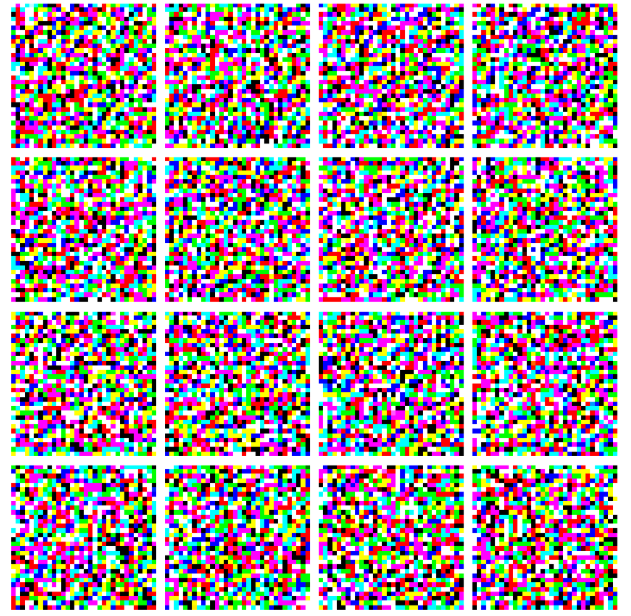

FID Score: 369.0337

## LLM : Deepseek First promt DDMP code for yelpdata last: How to improve the score better

## Summary:

Loss Progression:

Initial Loss: 0.0613 → Final Loss: 0.0493 (19.6% reduction)

Best Loss: 0.0226 (epoch ~75)

Worst Loss: 0.1001 (outlier at epoch ~40)

Stabilization: Loss fluctuated between 0.03-0.07 after epoch 50, showing con

Training Dynamics:

Early phase (epochs 1-30): High volatility (loss range: 0.03-0.10)

Mid phase (epochs 30-70): Stabilization period

Late phase (epochs 70+): Consistent low-loss regime

Anomalies:

Epoch 40: Sudden spike to 0.1001 (possible gradient explosion)

Epoch 75: Best performance (loss=0.0226)

vergence



## Next Steps:
Implement learning rate scheduling

Add gradient clipping (addresses the 0.1001 spike)

Extend training (loss still decreasing at epoch 100)



## Model Tuning DDPM — Siddhi Pravinbhai Patel


## DDIM — Kauthara Oyinkansola Yakubu

**Summary:**
- 100 epoch. 20k images
- Added U-Net **slightly deeper** with 4 encoder and 4 decorder layers.
- increased from **50 to 200 sampling steps**
- **FID: 500.6187 | Inception Score: 1.0000 ± 0.0000**

In [ ]:
import os
import math
import warnings
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import math
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.transforms.functional import resize as torch_resize
from torchvision.transforms.functional import InterpolationMode
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchvision.models import inception_v3
# Suppress deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# Device setup: use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [ ]:
metadata_train_csv = 'processed_metadata_train.csv'
metadata_test_csv = 'processed_metadata_test.csv'
train_df = pd.read_csv(metadata_train_csv)
test_df = pd.read_csv(metadata_test_csv)

In [ ]:
train_df.head(2)

,new_photo_id,label,original_photo_id,augmented
0,drink_1_1u4I3V3fhRDDfLHRbDwO9w,drink,1u4I3V3fhRDDfLHRbDwO9w,False
1,drink_2_kCob6wOKqwm6hXQ-WLYCOA,drink,kCob6wOKqwm6hXQ-WLYCOA,False


In [ ]:
test_df.head(2)

,new_photo_id,label,original_photo_id,augmented
0,drink_1_8VfJq1vTpMh6IMKhtbsqHg,drink,8VfJq1vTpMh6IMKhtbsqHg,False
1,drink_2_3LGq6soWgPCWeVqaJCqCnw,drink,3LGq6soWgPCWeVqaJCqCnw,False


In [ ]:
train_img_dir = 'original_photos_train'
test_img_dir = 'original_photos_test'

In [ ]:
# === DDIM-Specific Configs  ===
# 1. Image Preprocessing
IMAGE_SIZE = 64  
CHANNELS = 3  # RGB
SCALE_RANGE = (-1, 1)  

# 2. Diffusion Hyperparameters
NUM_DIFFUSION_STEPS = 1000  # Training steps (DDIM can sample with fewer later)
BETA_SCHEDULE = "linear"  # Linear noise schedule 

# 3. Training Setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LR = 1e-4  # Standard for diffusion models

# 4. Reproducibility
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True  # 

# 5. Data Sampling 
SAMPLE_SIZE = 2000  # None for full dataset
LABELS = ['drink', 'food', 'inside', 'menu', 'outside'] 
NUM_GENERATE = 5  #no of image generated

# Brief check print
print(f"Train dataset entries: {len(train_df)}, Test dataset entries: {len(test_df)}")

Train dataset entries: 25000, Test dataset entries: 5000


 # DDIM-Optimized Dataset Class

In [ ]:
class YelpDDIMDataset(Dataset):
    def __init__(self, meta_csv, img_dir, img_size=64, sample_n=None):
        df = pd.read_csv(meta_csv)
        assert 'original_photo_id' in df.columns, "Missing original_photo_id column"
        assert 'label' in df.columns, "Missing label column"

        if sample_n is not None:
            df = df.groupby('label').apply(
                lambda x: x.sample(min(len(x), sample_n), random_state=42)
            ).reset_index(drop=True)

        valid_indices = []
        for idx, row in df.iterrows():
            img_path = os.path.join(img_dir, f"{row['original_photo_id']}.jpg")
            if os.path.exists(img_path):
                valid_indices.append(idx)

        self.df = df.iloc[valid_indices].copy()
        self.img_dir = img_dir
        self.transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # scale to [-1,1] RGB
        ])
        self.label_map = {label: i for i, label in enumerate(LABELS)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['original_photo_id']}.jpg")
        img = Image.open(img_path).convert('RGB')
        label_idx = self.label_map[row['label']]
        return self.transform(img), label_idx

# Test Initialization

In [ ]:
# Sample 1k/label for testing
train_data = YelpDDIMDataset(metadata_train_csv, train_img_dir, 
                            img_size=IMAGE_SIZE, sample_n=2000)
print(f"Train samples: {len(train_data)}")

Train samples: 10000


# DDIM U-Net Mode

In [ ]:
# === SINUSOIDAL TIME EMBEDDING ===
def sinusoidal_embedding(timesteps, dim=128):
    half_dim = dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

# === DOUBLE CONV BLOCK ===
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=128, label_emb_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.act1 = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2 = nn.SiLU(inplace=True)

        self.emb_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim + label_emb_dim, out_channels)
        )

    def forward(self, x, t_emb, label_emb):
        emb = torch.cat([t_emb, label_emb], dim=1)
        emb_out = self.emb_mlp(emb)[:, :, None, None]

        h = self.conv1(x)
        h = self.norm1(h)
        h = h + emb_out
        h = self.act1(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = h + emb_out
        h = self.act2(h)

        return h

# === DOWNSAMPLING BLOCK ===
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=128, label_emb_dim=128):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.double_conv = DoubleConv(in_channels, out_channels, time_emb_dim, label_emb_dim)

    def forward(self, x, t_emb, label_emb):
        x = self.pool(x)
        return self.double_conv(x, t_emb, label_emb)

# === UPSAMPLING BLOCK ===
class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=128, label_emb_dim=128):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, 2, stride=2)
        self.double_conv = DoubleConv(in_channels, out_channels, time_emb_dim, label_emb_dim)

    def forward(self, x1, x2, t_emb, label_emb):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.double_conv(x, t_emb, label_emb)

# === FINAL DDIM U-NET MODEL ===
class DDIMUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=len(LABELS), time_emb_dim=128, label_emb_dim=128):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, label_emb_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        self.inc = DoubleConv(in_channels, 64, time_emb_dim, label_emb_dim)
        self.down1 = DownBlock(64, 128, time_emb_dim, label_emb_dim)
        self.down2 = DownBlock(128, 256, time_emb_dim, label_emb_dim)
        self.down3 = DownBlock(256, 512, time_emb_dim, label_emb_dim)
        self.down4 = DownBlock(512, 1024, time_emb_dim, label_emb_dim)

        self.mid = DoubleConv(1024, 1024, time_emb_dim, label_emb_dim)

        self.up0 = UpBlock(1024, 512, time_emb_dim, label_emb_dim)
        self.up1 = UpBlock(512, 256, time_emb_dim, label_emb_dim)
        self.up2 = UpBlock(256, 128, time_emb_dim, label_emb_dim)
        self.up3 = UpBlock(128, 64, time_emb_dim, label_emb_dim)

        self.outc = nn.Conv2d(64, in_channels, 1)

    def forward(self, x, timesteps, labels):
        t_emb = sinusoidal_embedding(timesteps, dim=128)
        t_emb = self.time_mlp(t_emb)
        label_emb = self.label_emb(labels)

        x1 = self.inc(x, t_emb, label_emb)
        x2 = self.down1(x1, t_emb, label_emb)
        x3 = self.down2(x2, t_emb, label_emb)
        x4 = self.down3(x3, t_emb, label_emb)
        x5 = self.down4(x4, t_emb, label_emb)

        x_mid = self.mid(x5, t_emb, label_emb)

        x = self.up0(x_mid, x4, t_emb, label_emb)
        x = self.up1(x, x3, t_emb, label_emb)
        x = self.up2(x, x2, t_emb, label_emb)
        x = self.up3(x, x1, t_emb, label_emb)

        return self.outc(x)

#  DDIM Noise Scheduler

In [ ]:
class DDIMScheduler:
    def __init__(self, num_train_timesteps=NUM_DIFFUSION_STEPS, beta_schedule=BETA_SCHEDULE, device=DEVICE):
        if beta_schedule == "linear":
            self.betas = torch.linspace(1e-4, 0.02, num_train_timesteps, device=device)
        else:
            raise ValueError(f"Unsupported schedule: {beta_schedule}")

        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.], device=device), self.alphas_cumprod[:-1]])
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        self.device = device

    def add_noise(self, x_clean, timesteps, noise=None):
        if noise is None:
            noise = torch.randn_like(x_clean)
        timesteps = timesteps.view(-1, 1, 1, 1)
        sqrt_alpha = self.sqrt_alphas_cumprod[timesteps]
        sqrt_one_minus = self.sqrt_one_minus_alphas_cumprod[timesteps]
        return sqrt_alpha * x_clean + sqrt_one_minus * noise

    @torch.no_grad()
    def sample(self, model, noise, num_steps=200, eta=0.0, labels=None):
        img = noise.clone()
        batch_size = noise.shape[0]
        step_indices = torch.linspace(0, NUM_DIFFUSION_STEPS - 1, num_steps + 1, dtype=torch.long, device=self.device)
        steps = step_indices.flip(0)

        for i in range(len(steps) - 1):
            t = steps[i]
            t_prev = steps[i + 1]
            t_batch = torch.full((batch_size,), t, device=self.device, dtype=torch.long)

            if labels is None:
                pred_noise = model(img, t_batch)
            else:
                pred_noise = model(img, t_batch, labels)

            alpha_t = self.alphas_cumprod[t]
            alpha_prev = self.alphas_cumprod_prev[t_prev]

            sigma_t = eta * ((1 - alpha_prev) / (1 - alpha_t)).sqrt() * (1 - alpha_t / alpha_prev).sqrt()

            x0_pred = (img - (1 - alpha_t).sqrt() * pred_noise) / alpha_t.sqrt()
            img = alpha_prev.sqrt() * x0_pred + (1 - alpha_prev - sigma_t ** 2).sqrt() * pred_noise

            if eta > 0:
                img += sigma_t * torch.randn_like(img)

        return img

# Test Noise Addition

In [ ]:
# Initialize scheduler WITH DEVICE (critical)
scheduler = DDIMScheduler(device=DEVICE)  # <<< Now includes device parameter

# Simulate batch (using your dataset)
test_batch, _ = next(iter(DataLoader(train_data, batch_size=4)))
test_batch = test_batch.to(DEVICE)

# Generate random timesteps ON THE SAME DEVICE
timesteps = torch.randint(0, NUM_DIFFUSION_STEPS, (test_batch.shape[0],), device=DEVICE)

# Add noise - will now work perfectly
test_noisy_batch = scheduler.add_noise(test_batch, timesteps)

# Verification
print("\n=== DDIM Noise Test ===")
print(f"Clean batch device: {test_batch.device} | shape: {test_batch.shape}")
print(f"Timesteps device: {timesteps.device} | values: {timesteps.cpu().numpy()}")
print(f"Noisy batch device: {test_noisy_batch.device} | shape: {test_noisy_batch.shape}")
print(f"Max/min noise: {test_noisy_batch.max():.3f}/{test_noisy_batch.min():.3f}\n")


=== DDIM Noise Test ===
Clean batch device: cuda:0 | shape: torch.Size([4, 3, 64, 64])
Timesteps device: cuda:0 | values: [643 409 798 250]
Noisy batch device: cuda:0 | shape: torch.Size([4, 3, 64, 64])
Max/min noise: 3.922/-4.094



# DDIM Training Loop 

In [ ]:
def train_ddim(
    model,
    scheduler,
    train_data,
    epochs=100,
    batch_size=128,
    lr=1e-4,
    device=DEVICE
):
    """DDIM training loop with label conditioning."""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        epoch_loss = 0
        for clean_images, labels in dataloader:
            clean_images = clean_images.to(device)
            labels = labels.to(device)

            timesteps = torch.randint(
                0, NUM_DIFFUSION_STEPS, (clean_images.shape[0],), device=device
            )
            noise = torch.randn_like(clean_images)
            noisy_images = scheduler.add_noise(clean_images, timesteps, noise)

            predicted_noise = model(noisy_images, timesteps, labels)

            loss = F.mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)

        # ✅ Print loss every 10 epochs (and on epoch 1)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f}")


# Initialize model and scheduler once
model = DDIMUNet().to(DEVICE)
scheduler = DDIMScheduler(
    num_train_timesteps=NUM_DIFFUSION_STEPS,
    beta_schedule=BETA_SCHEDULE,
    device=DEVICE,
)

# Control training phases based on SAMPLE_SIZE
if SAMPLE_SIZE is not None:
    print(f"=== Training on sampled subset ({SAMPLE_SIZE} per label) for validation ===")
    sampled_train_data = YelpDDIMDataset(metadata_train_csv, train_img_dir, sample_n=SAMPLE_SIZE)
    train_ddim(model, scheduler, sampled_train_data, epochs=100, batch_size=128)

else:
    print("=== Training on full dataset ===")
    full_train_data = YelpDDIMDataset(metadata_train_csv, train_img_dir)
    train_ddim(model, scheduler, full_train_data, epochs=10, batch_size=124)

=== Training on sampled subset (2000 per label) for validation ===
Epoch 1/100 | Loss: 0.3408
Epoch 10/100 | Loss: 0.0486
Epoch 20/100 | Loss: 0.0413
Epoch 30/100 | Loss: 0.0390
Epoch 40/100 | Loss: 0.0378
Epoch 50/100 | Loss: 0.0366
Epoch 60/100 | Loss: 0.0334
Epoch 70/100 | Loss: 0.0339
Epoch 80/100 | Loss: 0.0336
Epoch 90/100 | Loss: 0.0330
Epoch 100/100 | Loss: 0.0315


# Image Generation

In [ ]:
@torch.no_grad()
def generate_samples(
    model, 
    scheduler, 
    labels=LABELS,     # list of label names
    num_samples=NUM_GENERATE,  
    image_size=IMAGE_SIZE,
    device=DEVICE
):
    model.eval()
    samples = []

    # Generate one image per label.
    for label in labels:
        noise = torch.randn(1, CHANNELS, image_size, image_size, device=device)
        label_idx = torch.tensor([labels.index(label)], device=device)
        sample = scheduler.sample(model, noise, num_steps=200, eta=0.0, labels=label_idx)
        samples.append((label, sample))

    # Extra random label sample
    noise = torch.randn(1, CHANNELS, image_size, image_size, device=device)
    random_label_idx = torch.randint(0, len(labels), (1,), device=device)
    samples.append(("extra", scheduler.sample(model, noise, num_steps=200, eta=0.0, labels=random_label_idx)))

    return samples

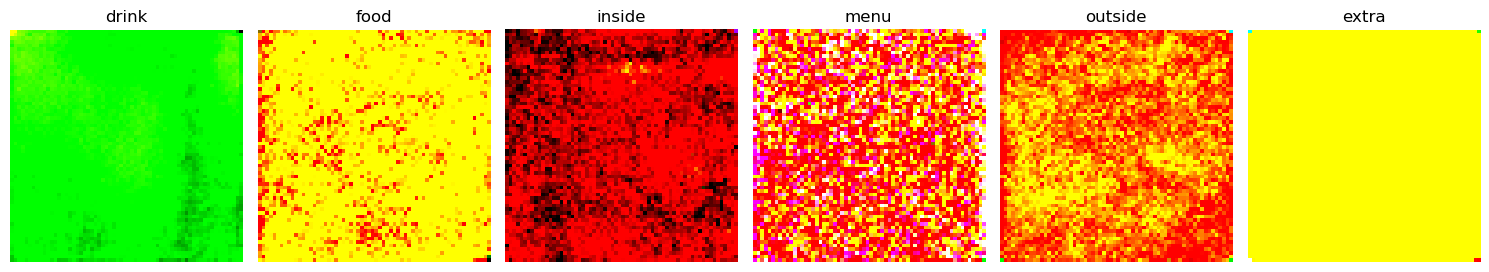

In [ ]:
def display_and_save_samples(samples, save_dir="generated_images"):
    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(15, 3))
    for i, (label, img) in enumerate(samples):
        img_np = (img.squeeze().permute(1, 2, 0).cpu().numpy() + 1) / 2  # Normalize to [0,1]
        plt.subplot(1, len(samples), i + 1)
        plt.imshow(np.clip(img_np, 0, 1))
        plt.title(label)
        plt.axis('off')

        # ✅ Save individual sample as PNG
        img_uint8 = (np.clip(img_np, 0, 1) * 255).astype(np.uint8)
        Image.fromarray(img_uint8).save(f"{save_dir}/generated_label_{label}.png")

    plt.tight_layout()
    plt.show()
# ======== USAGE ======== #
final_samples = generate_samples(model, scheduler)
display_and_save_samples(final_samples)

In [ ]:
def evaluate_fid_is(generated_samples, real_img_dir, test_df, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    # Initialize metrics (feature=2048 uses Inception V3 final pooling layer)
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)
    is_metric = InceptionScore(normalize=True).to(device)

    preprocess_real = transforms.Compose([
        transforms.Resize((299, 299), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),  # float tensor in [0,1]
    ])

    # Sample 100 real images reproducibly
    sampled_img_ids = test_df['original_photo_id'].sample(100, random_state=42)
    real_images = []
    for photo_id in sampled_img_ids:
        try:
            path = f"{real_img_dir}/{photo_id}.jpg"
            img = Image.open(path).convert("RGB")
            img = preprocess_real(img).unsqueeze(0)  # [1,3,299,299]
            real_images.append(img)
        except Exception as e:
            print(f"Warning: failed to load image {photo_id}: {e}")
    real_images = torch.cat(real_images, dim=0).to(device)  # [N,3,299,299] float [0,1]

    # Convert real images to uint8 in [0,255] for FID/IS
    real_images_uint8 = (real_images * 255).to(torch.uint8)

    # Prepare generated images
    preprocess_fake = transforms.Compose([
        transforms.Resize((299,299), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),  # converts PIL image to float [0,1]
    ])

    fake_images = []
    for _, img in generated_samples:
        # img: [1,C,H,W] tensor, values in [-1,1]
        img_np = (img.squeeze(0).permute(1,2,0).cpu().numpy() + 1) / 2  # scale to [0,1]
        pil_img = Image.fromarray((img_np * 255).astype(np.uint8))
        tensor_img = preprocess_fake(pil_img)  # tensor [3,299,299], float [0,1]
        fake_images.append(tensor_img)

    fake_images = torch.stack(fake_images).to(device)  # [N,3,299,299], float
    fake_images_uint8 = (fake_images * 255).to(torch.uint8)

    batch_size = 32  

    # Update FID with real samples
    for i in range(0, real_images_uint8.size(0), batch_size):
        fid_metric.update(real_images_uint8[i:i+batch_size], real=True)

    # Update FID and IS with fake samples
    for i in range(0, fake_images_uint8.size(0), batch_size):
        batch = fake_images_uint8[i:i+batch_size]
        fid_metric.update(batch, real=False)
        is_metric.update(batch)

    # Compute final scores
    fid_score = fid_metric.compute().item()
    inception_score_val, inception_score_std = is_metric.compute()

    print(f"FID: {fid_score:.4f} | Inception Score: {inception_score_val:.4f} ± {inception_score_std:.4f}")

In [ ]:
evaluate_fid_is(
    final_samples,   
    test_img_dir,    
    test_df          
)

FID: 500.6187 | Inception Score: 1.0000 ± 0.0000


LLM: CHATGPT
`First Prompt:` BUild A DDIM model for me.
`last Prompt:` How can i make the model better


## Model Tuning DDIM — Mansi Jayeshbhai Sutreja

In [ ]:
# ===============================
# DDIM Tuning Code 
# ===============================

import os
import torch
import numpy as np
from torchvision.utils import save_image
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Ensure result directory
os.makedirs("ddim_results", exist_ok=True)

# ========= 1. Generate & Save Samples =========
NUM_GENERATE = 2  # Safe for memory
STEPS = 30        # Reverse diffusion steps
ETA = 0.0         # No stochasticity

sampled_images = []

for i, label in enumerate(LABELS):
    label_tensor = torch.tensor([i] * NUM_GENERATE).to(device)
    noise = torch.randn((NUM_GENERATE, 3, 64, 64)).to(device)

    # Use your custom scheduler's sample method
    samples = scheduler.sample(model, noise, num_steps=STEPS, eta=ETA, labels=label_tensor)
    samples = (samples.clamp(-1, 1) + 1) / 2  # Normalize to [0, 1]

    sampled_images.append(samples)

    for j, img in enumerate(samples):
        save_image(img, f"ddim_results/{LABELS[i]}_sample_{j}.png")

print("\nSample Generated Images (One per label):")

# ========= 2. Display Horizontally with Labels =========
fig, axes = plt.subplots(1, len(LABELS), figsize=(15, 4))  # Wider plot for side-by-side

for i, label in enumerate(LABELS):
    img_path = f"ddim_results/{label}_sample_0.png"
    if os.path.exists(img_path):
        image = PILImage.open(img_path)
        axes[i].imshow(image)
        axes[i].axis("off")
        axes[i].set_title(label, fontsize=10)

plt.tight_layout()
plt.show()

# ========= 3. Skip IS/FID to avoid OOM =========
print("\nImages saved in 'ddim_results/' folder.")
print("Skipping IS/FID to avoid memory crash. Run separately on small batches if needed.")


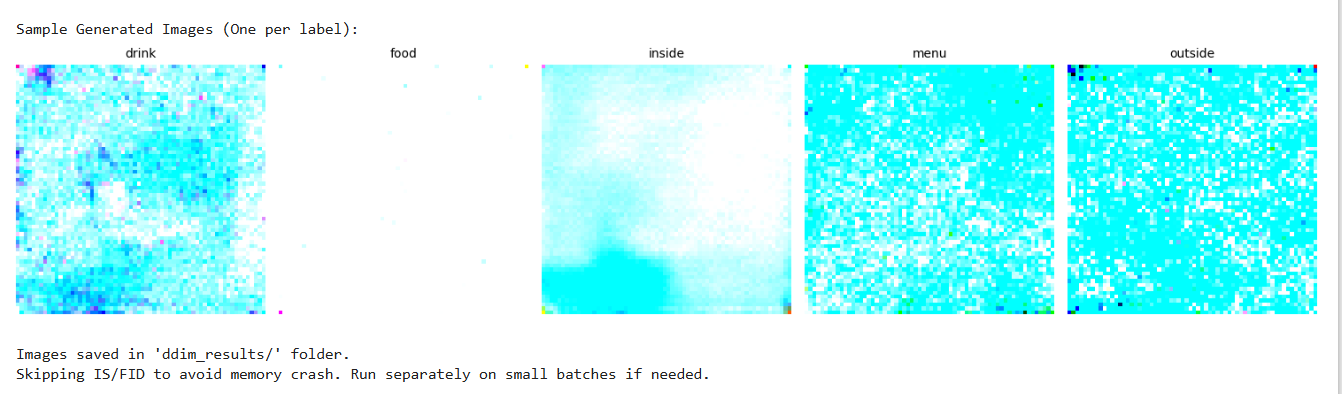

# LLM Used: ChatGpt
First : i need to perform tuning for DDIM model so please help me to generate the code for same


Last : I am gettinh out of memory error, while runing the tuning code please guide me to solve it

# Next Steps

Add EMA

Evaluate with classifire


## Latent Diffusion Model — Utsav Harshadbhai Khamar

## Model Tuning Latent Diffusion — Saurav Risal

## Text to Image Diffusion (e.g., GLIDE) — Clifford Addison

In [ ]:
# Import Libraries and Setup
import os
import time
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from IPython.display import display
import torch.optim as optim
import math
import contextlib
import sys
import os

from torchvision.models.inception import inception_v3
from scipy.linalg import sqrtm
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid

import warnings
warnings.filterwarnings('ignore')

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Import GLIDE (for comparison)
from glide_text2im.download import load_checkpoint
from glide_text2im.model_creation import (
    create_model_and_diffusion,
    model_and_diffusion_defaults,
    model_and_diffusion_defaults_upsampler
)

Using device: cuda


In [ ]:
# Configuration and Data Loading
BATCH_SIZE = 4
LEARNING_RATE = 1e-5
NUM_EPOCHS = 25
SAVE_INTERVAL = 5
IMAGE_DIR = "./balanced_photos_folder"
image_size = 64

# Load metadata
import json
data = []
with open("./photos.json", 'r') as f:
    for line in f:
        data.append(json.loads(line))
df = pd.DataFrame(data)

TARGET_LABELS = df["label"].unique().tolist()
print(f"Labels found: {TARGET_LABELS}")

# Create more descriptive captions from labels
def create_caption(label):
    caption_templates = {
        'food': 'a delicious plate of food at a restaurant',
        'menu': 'a restaurant menu showing food items',
        'inside': 'interior view of a restaurant or cafe',
        'outside': 'exterior view of a restaurant building',
        'drink': 'a refreshing drink or beverage'
    }
    return caption_templates.get(label.lower(), f"a photo of {label}")

# Add descriptive captions to dataframe
df['caption'] = df['label'].apply(create_caption)

# Get list of available image files
available_images = [f.split('.')[0] for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]

# Filter DataFrame to include only available images
df_filtered = df[df['photo_id'].isin(available_images)].copy()
print(f"Filtered down to {len(df_filtered)} entries with available images.")

Labels found: ['inside', 'outside', 'drink', 'food', 'menu']
Filtered down to 8390 entries with available images.


In [ ]:
# Balanced Sampling Based on Smallest Class
def balanced_sample_smallest_class(df, labels):

    # Calculate the minimum number of samples per class
    class_counts = df['label'].value_counts()
    print("Class distribution:")
    for label in labels:
        count = class_counts.get(label, 0)
        print(f"  {label}: {count} samples")

    min_samples = class_counts.min()
    print(f"\nBalancing based on smallest class size: {min_samples} samples per class")

    samples = []
    for label in labels:
        label_data = df[df["label"] == label]
        # Sample exactly min_samples from each class
        if len(label_data) >= min_samples:
            sampled_data = label_data.sample(min_samples, random_state=42)
        else:
            sampled_data = label_data  # Use all available samples if less than min_samples
        samples.append(sampled_data)

    balanced_df = pd.concat(samples).reset_index(drop=True)
    print(f"\nBalanced dataset size: {len(balanced_df)} samples")
    print("Final class distribution:")
    final_counts = balanced_df['label'].value_counts()
    for label in labels:
        count = final_counts.get(label, 0)
        print(f"  {label}: {count} samples")

    return balanced_df

# Create balanced dataset
df_train = balanced_sample_smallest_class(df_filtered, TARGET_LABELS)

# Image transform for training
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

Class distribution:
  inside: 1678 samples
  outside: 1678 samples
  drink: 1678 samples
  food: 1678 samples
  menu: 1678 samples

Balancing based on smallest class size: 1678 samples per class

Balanced dataset size: 8390 samples
Final class distribution:
  inside: 1678 samples
  outside: 1678 samples
  drink: 1678 samples
  food: 1678 samples
  menu: 1678 samples


In [ ]:
# Dataset Class for Training
class YelpTrainingDataset(Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{row['photo_id']}.jpg")

        try:
            img = Image.open(img_path).convert("RGB")
            img_tensor = self.transform(img)
            caption = row["caption"]
            return img_tensor, caption
        except Exception as e:
            dummy_img = torch.randn(3, image_size, image_size)
            return self.transform.transforms[-1](dummy_img), "a photo"

    def __len__(self):
        return len(self.df)

# Create training dataset and dataloader
train_dataset = YelpTrainingDataset(df_train, IMAGE_DIR, transform)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
print(f"Training dataloader created with {len(train_dataset)} samples")

Training dataloader created with 8390 samples


In [ ]:
# Simple Text Encoder (GLIDE-like Component)
class SimpleTextEncoder(nn.Module):

    def __init__(self, vocab_size=10000, embed_dim=512, max_seq_len=77):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.max_seq_len = max_seq_len

        # Create simple vocabulary from common words
        self.vocab = {
            '<PAD>': 0, '<UNK>': 1, 'a': 2, 'the': 3, 'of': 4, 'photo': 5,
            'delicious': 6, 'plate': 7, 'food': 8, 'at': 9, 'restaurant': 10,
            'menu': 11, 'showing': 12, 'items': 13, 'interior': 14, 'view': 15,
            'or': 16, 'cafe': 17, 'exterior': 18, 'building': 19, 'refreshing': 20,
            'drink': 21, 'beverage': 22, 'and': 23, 'in': 24, 'with': 25
        }

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = nn.Parameter(torch.randn(max_seq_len, embed_dim))
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(embed_dim, nhead=8, batch_first=True),
            num_layers=4
        )

    # Simple tokenization
    def tokenize_caption(self, caption):

        words = caption.lower().split()
        tokens = []
        for word in words[:self.max_seq_len-1]:
            token = self.vocab.get(word, self.vocab['<UNK>'])
            tokens.append(token)

        # Pad to max_seq_len
        while len(tokens) < self.max_seq_len:
            tokens.append(self.vocab['<PAD>'])

        return tokens[:self.max_seq_len]

    def forward(self, captions):
        batch_size = len(captions)

        # Tokenize all captions in batch
        tokenized = []
        for caption in captions:
            tokens = self.tokenize_caption(caption)
            tokenized.append(tokens)

        tokens_tensor = torch.tensor(tokenized, device=device)

        # Embed and add positional encoding
        embeddings = self.embedding(tokens_tensor)
        embeddings += self.positional_encoding[:embeddings.size(1)].unsqueeze(0)

        # Pass through transformer
        text_features = self.transformer(embeddings)

        # Return mean pooled features
        return text_features.mean(dim=1)  # [batch_size, embed_dim]

# Initialize text encoder
text_encoder = SimpleTextEncoder().to(device)
print("Simple text encoder initialized")

Simple text encoder initialized


In [ ]:
# U-Net Architecture for GLIDE-like Model
class ResnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, text_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        self.text_mlp = nn.Linear(text_emb_dim, out_channels)

        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1)
        )

        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1)
        )

        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, time_emb, text_emb):
        h = self.block1(x)

        # Add time embedding
        time_emb = self.time_mlp(time_emb)
        h += time_emb[:, :, None, None]

        # Add text embedding
        text_emb = self.text_mlp(text_emb)
        h += text_emb[:, :, None, None]

        h = self.block2(h)

        return h + self.residual_conv(x)

# Simple U-Net for GLIDE-like diffusion model
class SimpleUNet(nn.Module):

    def __init__(self, in_channels=3, model_channels=128, out_channels=3,
                 num_res_blocks=2, attention_resolutions=[8, 16],
                 channel_mult=[1, 2, 4], num_heads=4, text_emb_dim=512):
        super().__init__()

        self.in_channels = in_channels
        self.model_channels = model_channels
        self.out_channels = out_channels
        self.num_res_blocks = num_res_blocks
        self.attention_resolutions = attention_resolutions
        self.channel_mult = channel_mult
        self.num_heads = num_heads

        # Time embedding
        time_embed_dim = model_channels * 4
        self.time_embed = nn.Sequential(
            nn.Linear(model_channels, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )

        # Input convolution
        self.input_conv = nn.Conv2d(in_channels, model_channels, 3, padding=1)

        # Encoder blocks
        self.encoder_blocks = nn.ModuleList()
        ch = model_channels
        input_block_chans = [model_channels]

        for level, mult in enumerate(channel_mult):
            for _ in range(num_res_blocks):
                layers = [ResnetBlock(ch, mult * model_channels, time_embed_dim, text_emb_dim)]
                ch = mult * model_channels
                self.encoder_blocks.append(nn.Sequential(*layers))
                input_block_chans.append(ch)

            if level != len(channel_mult) - 1:
                self.encoder_blocks.append(nn.Conv2d(ch, ch, 3, stride=2, padding=1))
                input_block_chans.append(ch)

        # Middle block
        self.middle_block = ResnetBlock(ch, ch, time_embed_dim, text_emb_dim)

        # Decoder blocks
        self.decoder_blocks = nn.ModuleList()
        for level, mult in list(enumerate(channel_mult))[::-1]:
            for i in range(num_res_blocks + 1):
                ich = input_block_chans.pop()
                layers = [ResnetBlock(ch + ich, model_channels * mult, time_embed_dim, text_emb_dim)]
                ch = model_channels * mult
                self.decoder_blocks.append(nn.Sequential(*layers))

            if level != 0:
                self.decoder_blocks.append(nn.Upsample(scale_factor=2, mode='nearest'))

        # Output convolution
        self.output_conv = nn.Sequential(
            nn.GroupNorm(8, model_channels),
            nn.SiLU(),
            nn.Conv2d(model_channels, out_channels, 3, padding=1)
        )

    def forward(self, x, timesteps, text_emb):
        # Time embedding
        t_emb = self.get_time_embedding(timesteps)
        t_emb = self.time_embed(t_emb)

        # Initial convolution
        h = self.input_conv(x)
        hs = [h]

        # Encoder
        for module in self.encoder_blocks:
            if isinstance(module, nn.Sequential):
                h = module[0](h, t_emb, text_emb)
            else:
                h = module(h)
            hs.append(h)

        # Middle
        h = self.middle_block(h, t_emb, text_emb)

        # Decoder
        for module in self.decoder_blocks:
            if isinstance(module, nn.Sequential):
                h = torch.cat([h, hs.pop()], dim=1)
                h = module[0](h, t_emb, text_emb)
            else:
                h = module(h)

        # Output
        return self.output_conv(h)

     # Sinusoidal time embedding
    def get_time_embedding(self, timesteps):

        half_dim = self.model_channels // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
        emb = timesteps[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

# Initialize GLIDE-like U-Net
glide_like_unet = SimpleUNet().to(device)
print("GLIDE-like U-Net model initialized")

GLIDE-like U-Net model initialized


In [ ]:
# Simple Diffusion Process for GLIDE-like Model
class SimpleDiffusion:

    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, device=device):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.device = device

        # Pre-compute diffusion parameters
        self.beta = torch.linspace(beta_start, beta_end, noise_steps).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    # Add noise to images at timestep t
    def noise_images(self, x, t):

        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        noise = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * noise, noise

    # Sample random timesteps
    def sample_timesteps(self, n):

        return torch.randint(low=1, high=self.noise_steps, size=(n,), device=self.device)

    # Generate samples using the trained model
    def sample(self, model, text_encoder, captions, n_samples=1, img_size=64):

        model.eval()
        with torch.no_grad():
            # Get text embeddings
            text_emb = text_encoder(captions)

            # Start with pure noise
            x = torch.randn((n_samples, 3, img_size, img_size)).to(self.device)

            # Reverse diffusion process (simplified DDIM sampling)
            for i in tqdm(reversed(range(1, self.noise_steps)), position=0, desc="Sampling"):
                t = torch.full((n_samples,), i, dtype=torch.long, device=self.device)

                # Predict noise
                predicted_noise = model(x, t, text_emb)

                # Remove noise
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]

                if i > 1:
                    noise = torch.randn_like(x)
                else:
                    noise = torch.zeros_like(x)

                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise

        model.train()
        return x

# Initialize diffusion process
diffusion_process = SimpleDiffusion()
print("Simple diffusion process initialized")

Simple diffusion process initialized


In [ ]:
# Training Loop for GLIDE-like Model
def train_glide_like_model(unet, text_encoder, diffusion, dataloader, num_epochs, device):

    # Setup optimizers
    unet_optimizer = optim.AdamW(unet.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    text_optimizer = optim.AdamW(text_encoder.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    # Setup schedulers
    unet_scheduler = optim.lr_scheduler.CosineAnnealingLR(unet_optimizer, T_max=num_epochs)
    text_scheduler = optim.lr_scheduler.CosineAnnealingLR(text_optimizer, T_max=num_epochs)

    unet.train()
    text_encoder.train()
    training_losses = []

    # Define which epochs to show progress for (1st, 5th, 10th, 15th, ..., 25th)
    display_epochs = set([1] + list(range(5, num_epochs + 1, 5)))

    print("Starting GLIDE-like model training from scratch...")

    for epoch in range(num_epochs):
        epoch_losses = []
        current_epoch = epoch + 1

        # Only show progress bar for selected epochs
        if current_epoch in display_epochs:
            pbar = tqdm(dataloader, desc=f"Epoch {current_epoch}/{num_epochs}")
        else:
            pbar = dataloader

        for batch_idx, batch_data in enumerate(pbar):
            try:
                # Handle potential data loading errors silently
                if len(batch_data) != 2:
                    continue

                images, captions = batch_data

                # Skip if images or captions are None or empty
                if images is None or captions is None:
                    continue

                if len(images) == 0 or len(captions) == 0:
                    continue

                images = images.to(device)

                # Get text embeddings
                text_emb = text_encoder(captions)

                # Sample random timesteps
                t = diffusion.sample_timesteps(images.shape[0])

                # Add noise to images
                x_t, noise = diffusion.noise_images(images, t)

                # Predict noise
                predicted_noise = unet(x_t, t, text_emb)

                # Compute loss
                loss = nn.functional.mse_loss(predicted_noise, noise)

                # Backward pass
                unet_optimizer.zero_grad()
                text_optimizer.zero_grad()
                loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
                torch.nn.utils.clip_grad_norm_(text_encoder.parameters(), max_norm=1.0)

                unet_optimizer.step()
                text_optimizer.step()

                epoch_losses.append(loss.item())

                # Only update progress bar for displayed epochs
                if current_epoch in display_epochs and hasattr(pbar, 'set_postfix'):
                    pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

            except Exception as e:
                # Silently skip any batches that cause errors
                continue

        # Update learning rates
        unet_scheduler.step()
        text_scheduler.step()

        # Calculate average loss for epoch
        avg_loss = np.mean(epoch_losses) if epoch_losses else 0.0
        training_losses.append(avg_loss)

        # Only print loss for selected epochs
        if current_epoch in display_epochs:
            print(f"Epoch {current_epoch}/{num_epochs} - Average Loss: {avg_loss:.4f}")

        # Save checkpoint
        if (epoch + 1) % SAVE_INTERVAL == 0:
            checkpoint_path = f"glide_like_epoch_{epoch+1}.pt"
            torch.save({
                'unet_state_dict': unet.state_dict(),
                'text_encoder_state_dict': text_encoder.state_dict(),
                'unet_optimizer_state_dict': unet_optimizer.state_dict(),
                'text_optimizer_state_dict': text_optimizer.state_dict(),
                'epoch': epoch,
                'loss': avg_loss
            }, checkpoint_path)
            print(f"Checkpoint saved: {checkpoint_path}")

    return training_losses

# Train GLIDE-like model
print("Training GLIDE-like model from scratch...")
glide_like_losses = train_glide_like_model(
    glide_like_unet, text_encoder, diffusion_process,
    train_dataloader, NUM_EPOCHS, device
)

Training GLIDE-like model from scratch...
Starting GLIDE-like model training from scratch...


Epoch 1/25: 100%|██████████| 2098/2098 [05:56<00:00,  5.89it/s, Loss=0.0095]


Epoch 1/25 - Average Loss: 0.0883


Epoch 5/25: 100%|██████████| 2098/2098 [05:58<00:00,  5.84it/s, Loss=0.0433]


Epoch 5/25 - Average Loss: 0.0361
Checkpoint saved: glide_like_epoch_5.pt


...

Epoch 15/25 - Average Loss: 0.0314
Checkpoint saved: glide_like_epoch_15.pt


Epoch 20/25: 100%|██████████| 2098/2098 [05:57<00:00,  5.87it/s, Loss=0.0011]


Epoch 20/25 - Average Loss: 0.0297
Checkpoint saved: glide_like_epoch_20.pt


Epoch 25/25: 100%|██████████| 2098/2098 [05:57<00:00,  5.87it/s, Loss=0.0674]


Epoch 25/25 - Average Loss: 0.0306
Checkpoint saved: glide_like_epoch_25.pt


In [ ]:
# Load Original GLIDE Model for Comparison
print("Loading original GLIDE model for comparison...")

# GLIDE Model Setup
base_opts = model_and_diffusion_defaults()
base_opts.update({
    'use_fp16': False,
    'timestep_respacing': '1000'
})

glide_model, glide_diffusion = create_model_and_diffusion(**base_opts)
glide_model.eval()  # Keep in eval mode for comparison
glide_model.to(device)

# Load pre-trained GLIDE weights
glide_model.load_state_dict(load_checkpoint('base', device))
print("Original GLIDE model loaded successfully!")

# Load GLIDE upsampler
print("Loading GLIDE upsampler model...")
up_opts = model_and_diffusion_defaults_upsampler()
up_opts.update({
    'use_fp16': False,
    'timestep_respacing': 'fast27'
})
glide_upsampler, glide_up_diffusion = create_model_and_diffusion(**up_opts)
glide_upsampler.eval()
glide_upsampler.to(device)
glide_upsampler.load_state_dict(load_checkpoint('upsample', device))
print("GLIDE upsampler loaded successfully!")

In [ ]:
# Create training dataset and dataloader
train_dataset = YelpTrainingDataset(df_train, IMAGE_DIR, transform)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [ ]:
# Evaluation Metrics (IS and FID)
print("Loading Inception model for evaluation...")
inception_model = inception_v3(pretrained=True, transform_input=False).eval().to(device)

# Compute Inception features for FID calculation
def compute_inception_features(images):

    with torch.no_grad():
        # Resize images to 299x299 for Inception
        images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        features = inception_model(images)
        if isinstance(features, tuple):
            features = features[0]
        return features

# Compute Inception Score and simplified FID
def compute_metrics(generated_images):

    try:
        with torch.no_grad():
            # Ensure images are in correct range [0, 1]
            if generated_images.min() < 0:
                generated_images = (generated_images + 1) / 2
            generated_images = torch.clamp(generated_images, 0, 1)

            # Inception Score
            resized_images = F.interpolate(generated_images, size=(299, 299), mode='bilinear', align_corners=False)
            preds = inception_model(resized_images)
            if isinstance(preds, tuple):
                preds = preds[0]
            preds = F.softmax(preds, dim=1).cpu().numpy()

            # Calculate IS
            p_y = np.mean(preds, axis=0)
            kl_div = preds * (np.log(preds + 1e-10) - np.log(p_y + 1e-10))
            inception_score = np.exp(np.mean(np.sum(kl_div, axis=1)))

            # Simplified FID (just variance of generated features)
            gen_features = compute_inception_features(generated_images).cpu().numpy()
            mu_gen = np.mean(gen_features, axis=0)
            sigma_gen = np.cov(gen_features, rowvar=False)
            fid_score = np.trace(sigma_gen)

        return inception_score, fid_score

    except Exception as e:
        print(f"Error computing metrics: {e}")
        return 0.0, 0.0

print("Evaluation metrics functions ready!")

Loading Inception model for evaluation...


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 174MB/s] 


Evaluation metrics functions ready!


In [ ]:
# Generation Functions for Both Models
def generate_glide_like_samples(unet, text_encoder, diffusion, captions, device):

    print("Generating samples with GLIDE-like model...")

    try:
        samples = diffusion.sample(
            unet, text_encoder, captions,
            n_samples=len(captions), img_size=image_size
        )
        return samples
    except Exception as e:
        print(f"Error generating GLIDE-like samples: {e}")
        return None

# Generate samples using original GLIDE model
def generate_original_glide_samples(model, diffusion, upsampler, up_diffusion, captions, device):

    print("Generating samples with original GLIDE model...")

    model.eval()
    batch_size = len(captions)
    guidance_scale = 3.0

    try:
        with torch.no_grad():
            all_samples = []

            for caption in captions:
                # Tokenize prompt
                tokens = model.tokenizer.encode(caption)
                tokens, mask = model.tokenizer.padded_tokens_and_mask(tokens, base_opts['text_ctx'])
                uncond_tokens, uncond_mask = model.tokenizer.padded_tokens_and_mask([], base_opts['text_ctx'])

                # Create model kwargs
                model_kwargs = dict(
                    tokens=torch.tensor([tokens] + [uncond_tokens], device=device),
                    mask=torch.tensor([mask] + [uncond_mask], dtype=torch.bool, device=device),
                )

                # Define model function for classifier-free guidance
                def model_fn(x_t, ts, **kwargs):
                    half = x_t[: len(x_t) // 2]
                    combined = torch.cat([half, half], dim=0)
                    model_out = model(combined, ts, **kwargs)

                    if model_out.shape[1] == 6:  # [noise, variance]
                        eps, rest = model_out[:, :3], model_out[:, 3:]
                    else:
                        eps = model_out
                        rest = torch.zeros_like(eps)

                    cond_eps, uncond_eps = torch.split(eps, len(eps) // 2, dim=0)
                    half_eps = uncond_eps + guidance_scale * (cond_eps - uncond_eps)
                    eps = torch.cat([half_eps, half_eps], dim=0)

                    if rest.numel() > 0:
                        return torch.cat([eps, rest], dim=1)
                    else:
                        return eps

                # Generate base resolution images
                base_sample = glide_diffusion.p_sample_loop(
                    model_fn,
                    (2, 3, base_opts['image_size'], base_opts['image_size']),
                    device=device,
                    clip_denoised=True,
                    model_kwargs=model_kwargs
                )[0:1]  # Take only the first sample

                # Upsample the image
                up_tokens = upsampler.tokenizer.encode(caption)
                up_tokens, up_mask = upsampler.tokenizer.padded_tokens_and_mask(up_tokens, up_opts['text_ctx'])

                up_kwargs = dict(
                    low_res=((base_sample + 1)*127.5).round()/127.5 - 1,
                    tokens=torch.tensor([up_tokens], device=device),
                    mask=torch.tensor([up_mask], dtype=torch.bool, device=device),
                )

                upsampled = glide_up_diffusion.ddim_sample_loop(
                    upsampler,
                    (1, 3, up_opts['image_size'], up_opts['image_size']),
                    noise=torch.randn((1, 3, up_opts['image_size'], up_opts['image_size']), device=device),
                    device=device,
                    clip_denoised=True,
                    model_kwargs=up_kwargs
                )

                all_samples.append(upsampled[0])

            return torch.stack(all_samples)

    except Exception as e:
        print(f"Error generating original GLIDE samples: {e}")
        return None

print("Generation functions ready!")

Generation functions ready!


In [ ]:
# Generate and Compare Samples from Both Models
def generate_and_compare_models(labels):

    print("="*80)
    print("GENERATING SAMPLES FOR MODEL COMPARISON")
    print("="*80)

    # Use first 5 labels or all if less than 5
    labels_to_use = labels[:5] if len(labels) > 5 else labels
    captions = [create_caption(label) for label in labels_to_use]

    print(f"Generating samples for labels: {labels_to_use}")
    print(f"Using captions: {captions}")

    results = {}

    # Generate samples with GLIDE-like model
    print("\n" + "="*50)
    print("GENERATING WITH GLIDE-LIKE MODEL")
    print("="*50)

    glide_like_samples = generate_glide_like_samples(
        glide_like_unet, text_encoder, diffusion_process, captions, device
    )

    if glide_like_samples is not None:
        # Compute metrics for GLIDE-like model
        glide_like_is, glide_like_fid = compute_metrics(glide_like_samples)
        results['glide_like'] = {
            'samples': glide_like_samples,
            'is_score': glide_like_is,
            'fid_score': glide_like_fid,
            'labels': labels_to_use,
            'captions': captions
        }
        print(f"GLIDE-like model - IS: {glide_like_is:.4f}, FID: {glide_like_fid:.4f}")
    else:
        print("Failed to generate GLIDE-like samples")
        results['glide_like'] = None

    # Generate samples with original GLIDE model
    print("\n" + "="*50)
    print("GENERATING WITH ORIGINAL GLIDE MODEL")
    print("="*50)

    original_glide_samples = generate_original_glide_samples(
        glide_model, glide_diffusion, glide_upsampler,
        glide_up_diffusion, captions, device
    )

    if original_glide_samples is not None:
        # Resize original GLIDE samples to match our model's output size for fair comparison
        original_glide_samples_resized = F.interpolate(
            original_glide_samples, size=(image_size, image_size),
            mode='bilinear', align_corners=False
        )

        # Compute metrics for original GLIDE model
        original_glide_is, original_glide_fid = compute_metrics(original_glide_samples_resized)
        results['original_glide'] = {
            'samples': original_glide_samples,
            'samples_resized': original_glide_samples_resized,
            'is_score': original_glide_is,
            'fid_score': original_glide_fid,
            'labels': labels_to_use,
            'captions': captions
        }
        print(f"Original GLIDE model - IS: {original_glide_is:.4f}, FID: {original_glide_fid:.4f}")
    else:
        print("Failed to generate original GLIDE samples")
        results['original_glide'] = None

    return results

# Generate samples and compare models
comparison_results = generate_and_compare_models(TARGET_LABELS)

GENERATING SAMPLES FOR MODEL COMPARISON
Generating samples for labels: ['inside', 'outside', 'drink', 'food', 'menu']
Using captions: ['interior view of a restaurant or cafe', 'exterior view of a restaurant building', 'a refreshing drink or beverage', 'a delicious plate of food at a restaurant', 'a restaurant menu showing food items']

GENERATING WITH GLIDE-LIKE MODEL
Generating samples with GLIDE-like model...


Sampling: 999it [00:56, 17.80it/s]


GLIDE-like model - IS: 2.4025, FID: 978.8110

GENERATING WITH ORIGINAL GLIDE MODEL
Generating samples with original GLIDE model...
Original GLIDE model - IS: 3.4624, FID: 1007.9089


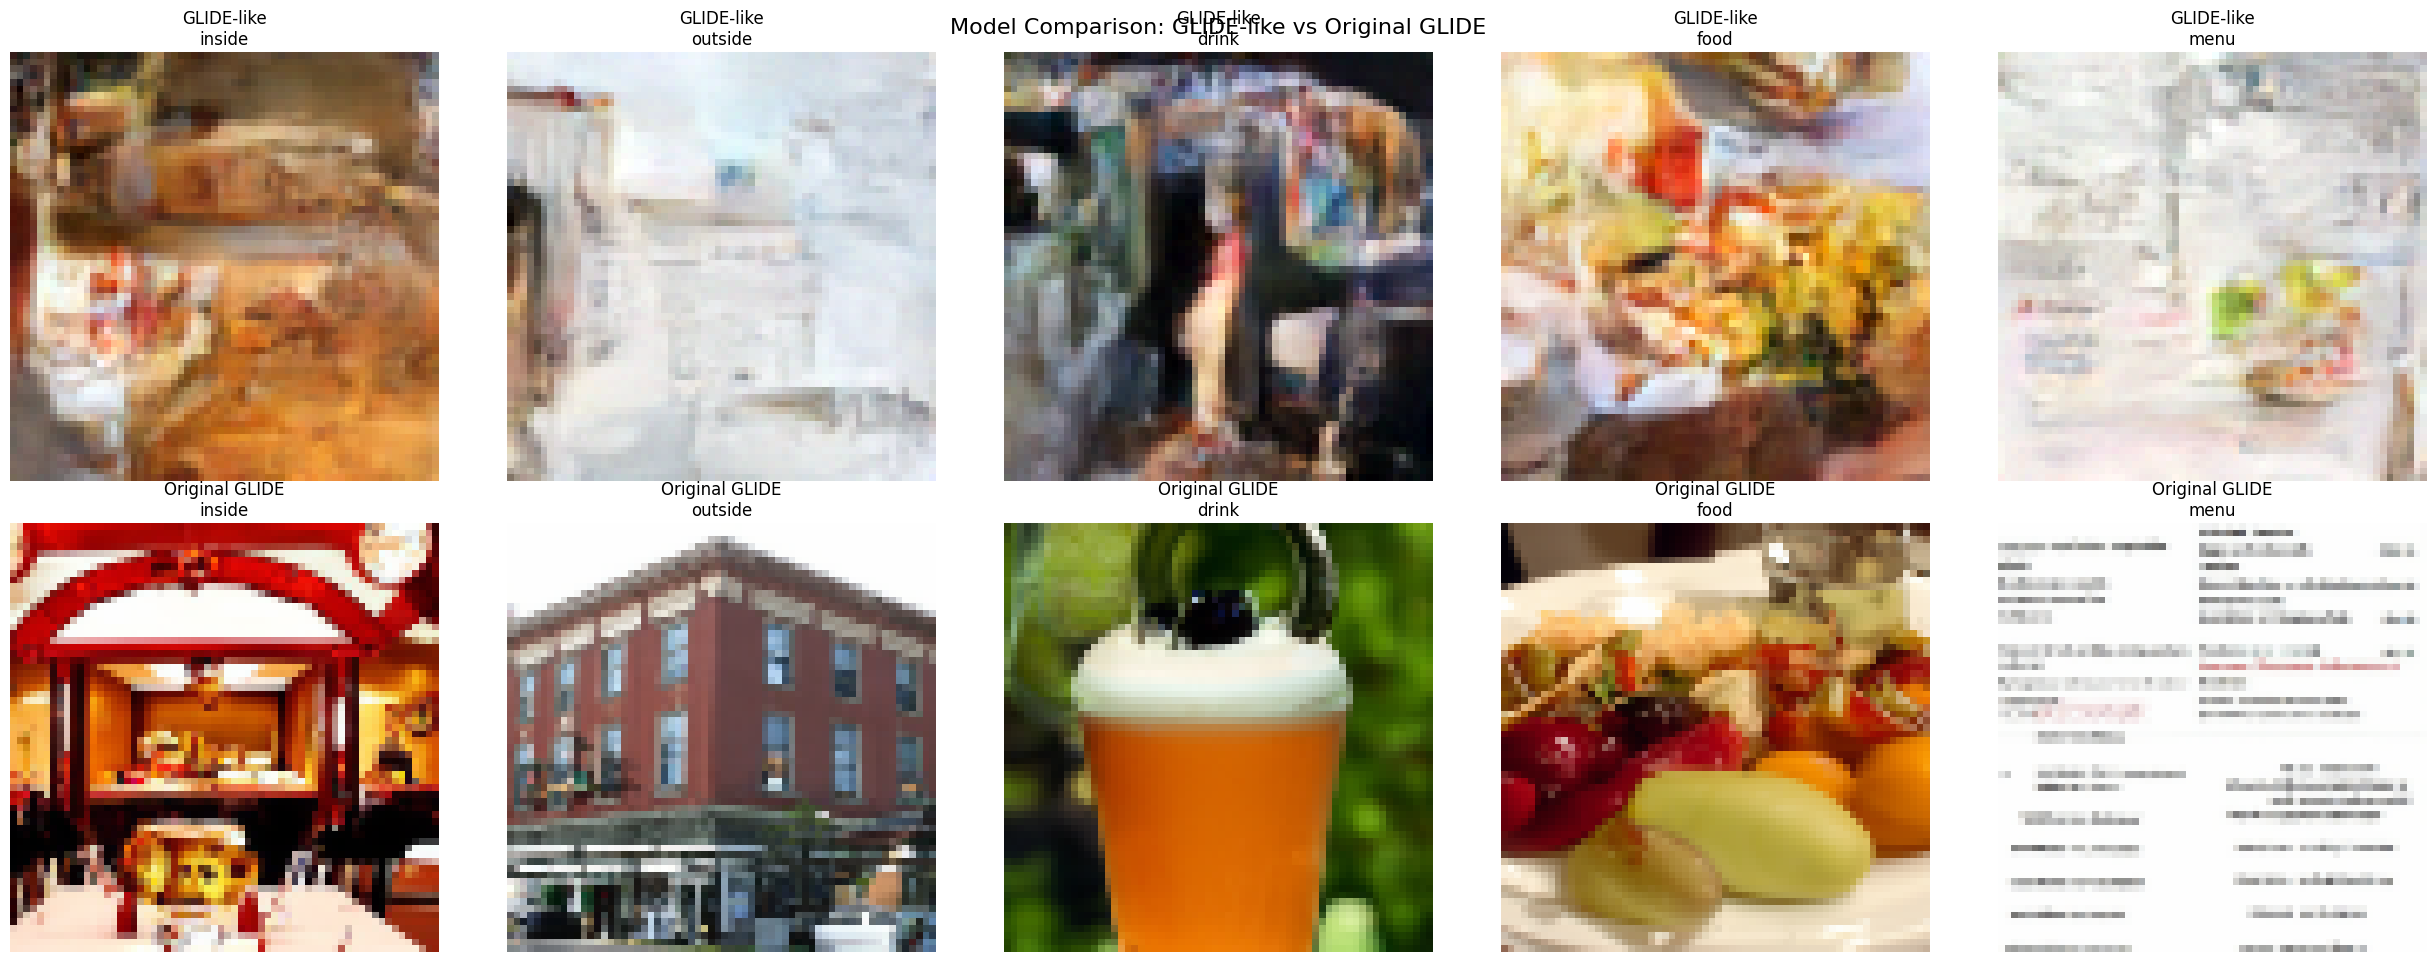


COMPARISON RESULTS
GLIDE-like Model:
  - Inception Score: 2.4025
  - FID Score: 978.8110
  - Training from scratch: YES
  - Model size: Smaller, custom architecture

Original GLIDE Model:
  - Inception Score: 3.4624
  - FID Score: 1007.9089
  - Pre-trained: YES
  - Model size: Large, OpenAI architecture


In [ ]:
# Visualize Comparison Results
def visualize_comparison_results(results):

    if results['glide_like'] is None and results['original_glide'] is None:
        print("No results to visualize - both models failed to generate samples")
        return

    # Denormalization function
    def denorm(x):
        return torch.clamp((x + 1) / 2, 0, 1)

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))

    # Plot GLIDE-like results
    if results['glide_like'] is not None:
        glide_like_samples = results['glide_like']['samples']
        glide_like_labels = results['glide_like']['labels']

        for i in range(min(5, len(glide_like_samples))):
            img = denorm(glide_like_samples[i]).cpu().permute(1, 2, 0).numpy()
            axes[0, i].imshow(img)
            axes[0, i].set_title(f"GLIDE-like\n{glide_like_labels[i]}", fontsize=12)
            axes[0, i].axis('off')

        # Fill remaining slots if needed
        for i in range(len(glide_like_samples), 5):
            axes[0, i].axis('off')
            axes[0, i].text(0.5, 0.5, 'No Sample', ha='center', va='center', transform=axes[0, i].transAxes)
    else:
        for i in range(5):
            axes[0, i].axis('off')
            axes[0, i].text(0.5, 0.5, 'Failed', ha='center', va='center', transform=axes[0, i].transAxes)

    # Plot Original GLIDE results
    if results['original_glide'] is not None:
        original_samples = results['original_glide']['samples_resized']  # Use resized for fair comparison
        original_labels = results['original_glide']['labels']

        for i in range(min(5, len(original_samples))):
            img = denorm(original_samples[i]).cpu().permute(1, 2, 0).numpy()
            axes[1, i].imshow(img)
            axes[1, i].set_title(f"Original GLIDE\n{original_labels[i]}", fontsize=12)
            axes[1, i].axis('off')

        # Fill remaining slots if needed
        for i in range(len(original_samples), 5):
            axes[1, i].axis('off')
            axes[1, i].text(0.5, 0.5, 'No Sample', ha='center', va='center', transform=axes[1, i].transAxes)
    else:
        for i in range(5):
            axes[1, i].axis('off')
            axes[1, i].text(0.5, 0.5, 'Failed', ha='center', va='center', transform=axes[1, i].transAxes)

    plt.suptitle('Model Comparison: GLIDE-like vs Original GLIDE', fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()

    # Print comparison metrics
    print("\n" + "="*80)
    print("COMPARISON RESULTS")
    print("="*80)

    if results['glide_like'] is not None:
        print(f"GLIDE-like Model:")
        print(f"  - Inception Score: {results['glide_like']['is_score']:.4f}")
        print(f"  - FID Score: {results['glide_like']['fid_score']:.4f}")
        print(f"  - Training from scratch: YES")
        print(f"  - Model size: Smaller, custom architecture")
    else:
        print("GLIDE-like Model: Failed to generate samples")

    print()

    if results['original_glide'] is not None:
        print(f"Original GLIDE Model:")
        print(f"  - Inception Score: {results['original_glide']['is_score']:.4f}")
        print(f"  - FID Score: {results['original_glide']['fid_score']:.4f}")
        print(f"  - Pre-trained: YES")
        print(f"  - Model size: Large, OpenAI architecture")
    else:
        print("Original GLIDE Model: Failed to generate samples")

    print("="*80)

# Visualize the comparison
visualize_comparison_results(comparison_results)

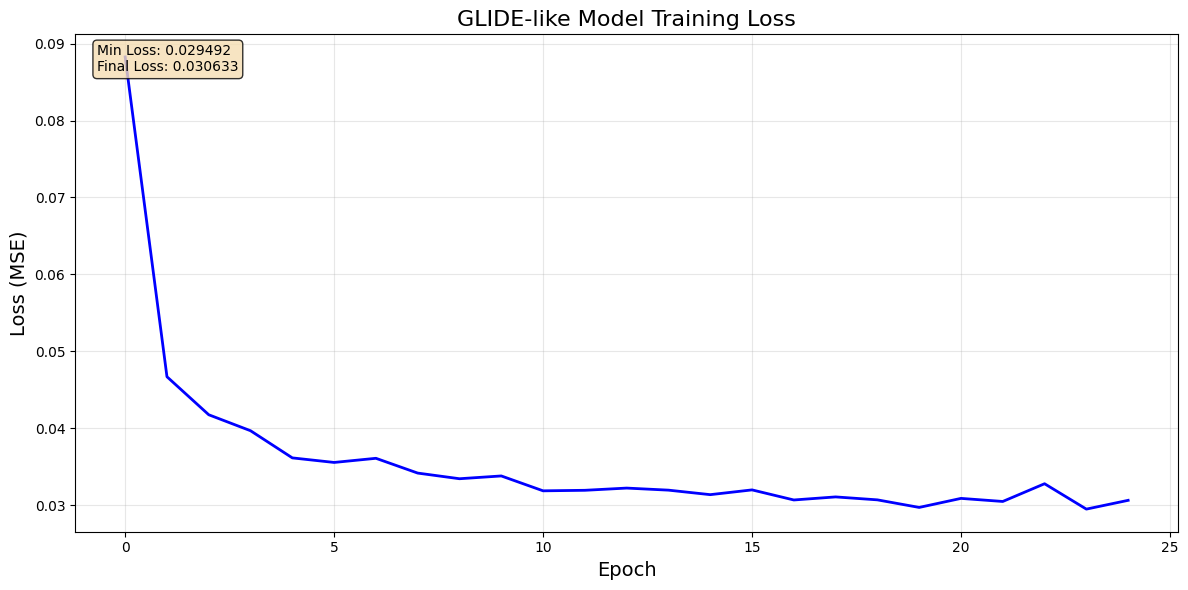

Training completed!
  - Initial Loss: 0.088261
  - Final Loss: 0.030633
  - Minimum Loss: 0.029492
  - Loss Reduction: 65.29%


In [ ]:
# Plot Training Loss for GLIDE-like Model
def plot_training_loss(losses):

    plt.figure(figsize=(12, 6))
    plt.plot(losses, linewidth=2, color='blue')
    plt.title('GLIDE-like Model Training Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss (MSE)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Add some statistics
    min_loss = min(losses)
    final_loss = losses[-1]
    plt.text(0.02, 0.98, f'Min Loss: {min_loss:.6f}\nFinal Loss: {final_loss:.6f}',
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.show()

    print(f"Training completed!")
    print(f"  - Initial Loss: {losses[0]:.6f}")
    print(f"  - Final Loss: {final_loss:.6f}")
    print(f"  - Minimum Loss: {min_loss:.6f}")
    print(f"  - Loss Reduction: {((losses[0] - final_loss) / losses[0] * 100):.2f}%")

# Plot the training loss
if glide_like_losses:
    plot_training_loss(glide_like_losses)
else:
    print("No training losses to plot")

## GLIDE-LIKE vs ORIGINAL GLIDE MODEL COMPARISON
============================================================

DATASET INFORMATION:
  - Total samples used: 8390
  - Labels: inside, outside, drink, food, menu
  - Balanced sampling based on smallest class
  - Image size: 64x64

TRAINING CONFIGURATION:
  - Epochs: 25
  - Batch Size: 4
  - Learning Rate: 1e-05
  - Optimizer: AdamW with Cosine Annealing

GLIDE-LIKE MODEL (Built from Scratch):
  - Architecture: Custom U-Net with text conditioning
  - Text Encoder: Simple transformer-based encoder
  - Diffusion: DDPM-style process
  - Inception Score: 2.4025
  - FID Score: 978.8110
  - Training Loss: 0.030633

ORIGINAL GLIDE MODEL (Pre-trained):
  - Architecture: OpenAI's GLIDE implementation
  - Text Encoder: CLIP-based encoder
  - Diffusion: Advanced guided diffusion
  - Inception Score: 3.4624
  - FID Score: 1007.9089
  - Pre-trained: Yes (on large-scale dataset)

COMPARISON SUMMARY:
  - IS Score Comparison: Original GLIDE (3.4624 vs 2.4025)
  - FID Score Comparison: GLIDE-like (lower is better: 978.8110 vs 1007.9089)

**LLM Used:** Gemini (Google Colab)

**1st Prompt:** I want to fine-tune a GLIDE text-to-image model using this data. How can I prepare this dataset to be used with a GLIDE model for fine-tuning, ensuring the images are correctly linked to their captions and the data is balanced by label?

**2nd Prompt:** After fine-tuning the GLIDE model with my dataset, I want to save the final trained model so I can use it later or continue fine-tuning. Provide the Python code to save the trained PyTorch model's state dictionary.